HASIL VALIDASI CLUSTERING: K-Means vs Agglomerative vs GMM
K=2 | Sil. K-Means: 0.5457 | Sil. Agglo: 0.5457 | Sil. GMM: 0.5091
K=3 | Sil. K-Means: 0.5899 | Sil. Agglo: 0.5899 | Sil. GMM: 0.3001
K=4 | Sil. K-Means: 0.4111 | Sil. Agglo: 0.4111 | Sil. GMM: 0.4111
K=5 | Sil. K-Means: 0.4031 | Sil. Agglo: 0.4031 | Sil. GMM: 0.4031
K=6 | Sil. K-Means: 0.4550 | Sil. Agglo: 0.4550 | Sil. GMM: 0.4086
K=7 | Sil. K-Means: 0.4156 | Sil. Agglo: 0.4156 | Sil. GMM: 0.4156
K=8 | Sil. K-Means: 0.2717 | Sil. Agglo: 0.2717 | Sil. GMM: 0.2717
K=9 | Sil. K-Means: 0.1824 | Sil. Agglo: 0.1824 | Sil. GMM: 0.1824


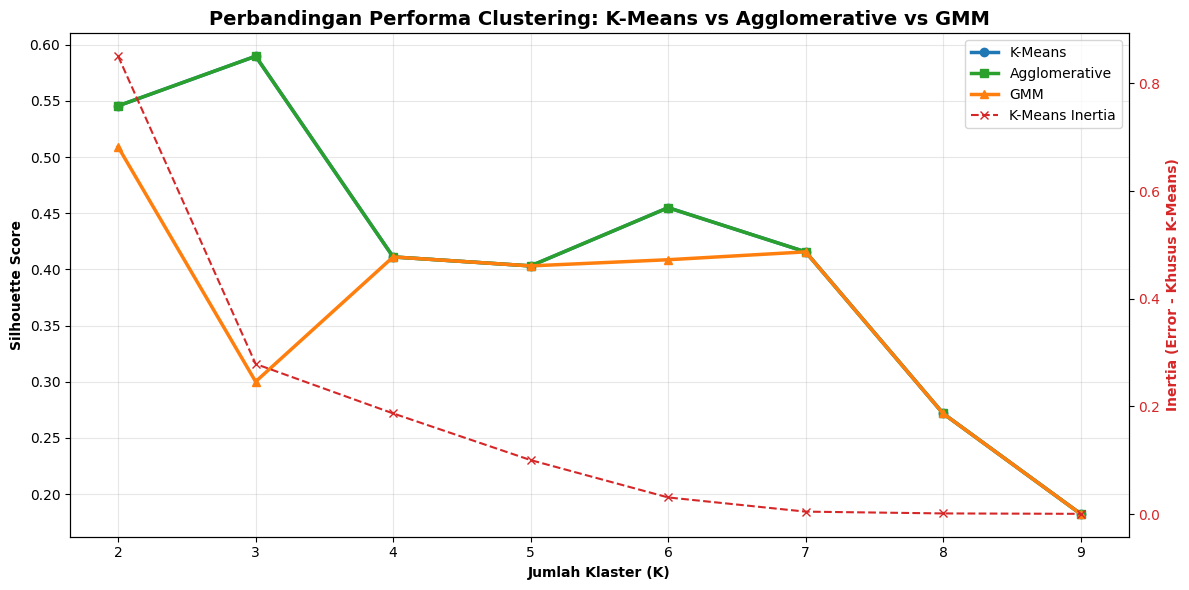


✅ Pemodelan Final Selesai! Data diekspor ke: 'final_dashboard_dataset_lengkap.csv'


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# =========================================================
# TAHAP 1: LOAD & MERGE DATA MASTER
# =========================================================
df_demand = pd.read_csv('master_demand_matrix_final.csv')
df_supply = pd.read_csv('master_supply_matrix_updated_with_revisions.csv')
df_master = pd.merge(df_demand, df_supply, on='DPP')

# =========================================================
# TAHAP 2: PIPELINE PREPROCESSING (DEMAND & SUPPLY)
# =========================================================
# -- DEMAND PIPELINE --
skewed_demand_cols = ['TikTok_Hashtag_Views', 'TikTok_Total_Engagement', 'GoogleMaps_Total_Reviews', 'IG_Total_Engagement']
other_demand_cols = ['Search_Volume_Score', 'GoogleMaps_Avg_Rating']

for col in skewed_demand_cols:
    df_master[col + '_log'] = np.log1p(df_master[col])

demand_features = [col + '_log' for col in skewed_demand_cols] + other_demand_cols
demand_robust = RobustScaler().fit_transform(df_master[demand_features])
demand_minmax = MinMaxScaler().fit_transform(demand_robust)

df_master['Demand_Score'] = demand_minmax.mean(axis=1)
df_master['Demand_Score'] = MinMaxScaler().fit_transform(df_master[['Demand_Score']])

# -- SUPPLY PIPELINE --
supply_cols = [
    'Supply_Total_Hotels', 'Supply_Avg_Hotel_Price', 'Supply_Avg_Hotel_Rating', 
    'Supply_Avg_Airport_Dist_KM', 'Supply_Avg_Port_Dist_KM', 'Flight_Frequency', 
    'Supply_Total_Restaurants', 'Supply_Avg_Restaurant_Rating', 
    'Supply_Total_Attractions', 'Supply_Avg_Attraction_Rating'
]

max_port_dist = df_master['Supply_Avg_Port_Dist_KM'].max()
df_master['Supply_Avg_Port_Dist_KM'] = df_master['Supply_Avg_Port_Dist_KM'].fillna(max_port_dist)

df_supply_scaled = pd.DataFrame(MinMaxScaler().fit_transform(df_master[supply_cols]), columns=supply_cols)
df_supply_scaled['Supply_Avg_Airport_Dist_KM'] = 1 - df_supply_scaled['Supply_Avg_Airport_Dist_KM']
df_supply_scaled['Supply_Avg_Port_Dist_KM'] = 1 - df_supply_scaled['Supply_Avg_Port_Dist_KM']

df_master['Supply_Score'] = df_supply_scaled.mean(axis=1)
df_master['Supply_Score'] = MinMaxScaler().fit_transform(df_master[['Supply_Score']])

# =========================================================
# TAHAP 3: ITERASI CLUSTERING K=2 HINGGA K=9 (PERBANDINGAN 3 METODE)
# =========================================================
print("="*70)
print("HASIL VALIDASI CLUSTERING: K-Means vs Agglomerative vs GMM")
print("="*70)

X = df_master[['Demand_Score', 'Supply_Score']]

kmeans_silhouette = []
agglo_silhouette = []
gmm_silhouette = []
inertia_values = [] # Inertia hanya valid untuk K-Means
K_range = range(2, 10)

for k in K_range:
    # 1. K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)
    kmeans_sil = silhouette_score(X, kmeans_labels)
    kmeans_silhouette.append(kmeans_sil)
    inertia_values.append(kmeans.inertia_)
    
    # 2. Agglomerative Hierarchical Clustering
    agglo = AgglomerativeClustering(n_clusters=k)
    agglo_labels = agglo.fit_predict(X)
    agglo_sil = silhouette_score(X, agglo_labels)
    agglo_silhouette.append(agglo_sil)
    
    # 3. Gaussian Mixture Model (GMM)
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm_labels = gmm.fit_predict(X)
    gmm_sil = silhouette_score(X, gmm_labels)
    gmm_silhouette.append(gmm_sil)
    
    print(f"K={k} | Sil. K-Means: {kmeans_sil:.4f} | Sil. Agglo: {agglo_sil:.4f} | Sil. GMM: {gmm_sil:.4f}")

# =========================================================
# TAHAP 4: VISUALISASI METRIK PERBANDINGAN 3 METODE
# =========================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Jumlah Klaster (K)', fontweight='bold')
ax1.set_ylabel('Silhouette Score', fontweight='bold')

# Plot ketiga metode
ax1.plot(K_range, kmeans_silhouette, marker='o', color='tab:blue', linewidth=2.5, label='K-Means')
ax1.plot(K_range, agglo_silhouette, marker='s', color='tab:green', linewidth=2.5, label='Agglomerative')
ax1.plot(K_range, gmm_silhouette, marker='^', color='tab:orange', linewidth=2.5, label='GMM')
ax1.tick_params(axis='y')

# Plot Inertia K-Means sebagai referensi tambahan (axis kanan)
ax2 = ax1.twinx()
ax2.set_ylabel('Inertia (Error - Khusus K-Means)', color='tab:red', fontweight='bold')
ax2.plot(K_range, inertia_values, marker='x', linestyle='dashed', color='tab:red', linewidth=1.5, label='K-Means Inertia')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Perbandingan Performa Clustering: K-Means vs Agglomerative vs GMM', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(K_range)

# Menggabungkan legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

fig.tight_layout()
plt.show()

# =========================================================
# TAHAP 5: EKSEKUSI MODEL FINAL & GAP ANALYSIS
# =========================================================
# Catatan: Pastikan nilai n_clusters sesuai dengan temuan akhir Anda (misal: 3)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_master['Cluster_Result'] = kmeans_final.fit_predict(X)

# Hitung Kesenjangan
df_master['Gap_Analysis'] = df_master['Demand_Score'] - df_master['Supply_Score']

# Simpan hasil akhir
final_columns = ['DPP', 'Demand_Score', 'Supply_Score', 'Gap_Analysis', 'Cluster_Result']
df_final = df_master[final_columns].sort_values(by='Gap_Analysis', ascending=False)
df_final.to_csv('final_dashboard_dataset_lengkap.csv', index=False)

print("\n✅ Pemodelan Final Selesai! Data diekspor ke: 'final_dashboard_dataset_lengkap.csv'")

HASIL VALIDASI CLUSTERING (K=2 hingga K=9)
Jumlah Klaster (K) = 2  |  Silhouette Score: 0.5457  |  Inertia: 0.8504
Jumlah Klaster (K) = 3  |  Silhouette Score: 0.5899  |  Inertia: 0.2789
Jumlah Klaster (K) = 4  |  Silhouette Score: 0.4111  |  Inertia: 0.1870
Jumlah Klaster (K) = 5  |  Silhouette Score: 0.4031  |  Inertia: 0.1003
Jumlah Klaster (K) = 6  |  Silhouette Score: 0.4550  |  Inertia: 0.0310
Jumlah Klaster (K) = 7  |  Silhouette Score: 0.4156  |  Inertia: 0.0046
Jumlah Klaster (K) = 8  |  Silhouette Score: 0.2717  |  Inertia: 0.0013
Jumlah Klaster (K) = 9  |  Silhouette Score: 0.1824  |  Inertia: 0.0005


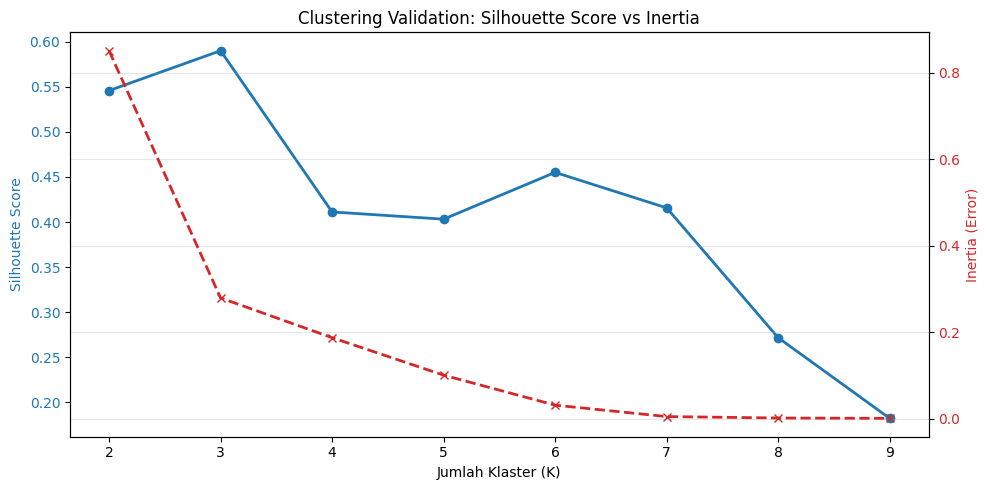


✅ Pemodelan Final Selesai! Data diekspor ke: 'final_dashboard_dataset_lengkap.csv'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =========================================================
# TAHAP 1: LOAD & MERGE DATA MASTER
# =========================================================
df_demand = pd.read_csv('master_demand_matrix_final.csv')
df_supply = pd.read_csv('master_supply_matrix_updated_with_revisions.csv')
df_master = pd.merge(df_demand, df_supply, on='DPP')

# =========================================================
# TAHAP 2: PIPELINE PREPROCESSING (DEMAND & SUPPLY)
# =========================================================
# -- DEMAND PIPELINE --
skewed_demand_cols = ['TikTok_Hashtag_Views', 'TikTok_Total_Engagement', 'GoogleMaps_Total_Reviews', 'IG_Total_Engagement']
other_demand_cols = ['Search_Volume_Score', 'GoogleMaps_Avg_Rating']

for col in skewed_demand_cols:
    df_master[col + '_log'] = np.log1p(df_master[col])

demand_features = [col + '_log' for col in skewed_demand_cols] + other_demand_cols
demand_robust = RobustScaler().fit_transform(df_master[demand_features])
demand_minmax = MinMaxScaler().fit_transform(demand_robust)

df_master['Demand_Score'] = demand_minmax.mean(axis=1)
df_master['Demand_Score'] = MinMaxScaler().fit_transform(df_master[['Demand_Score']])

# -- SUPPLY PIPELINE --
supply_cols = [
    'Supply_Total_Hotels', 'Supply_Avg_Hotel_Price', 'Supply_Avg_Hotel_Rating', 
    'Supply_Avg_Airport_Dist_KM', 'Supply_Avg_Port_Dist_KM', 'Flight_Frequency', 
    'Supply_Total_Restaurants', 'Supply_Avg_Restaurant_Rating', 
    'Supply_Total_Attractions', 'Supply_Avg_Attraction_Rating'
]

max_port_dist = df_master['Supply_Avg_Port_Dist_KM'].max()
df_master['Supply_Avg_Port_Dist_KM'] = df_master['Supply_Avg_Port_Dist_KM'].fillna(max_port_dist)

df_supply_scaled = pd.DataFrame(MinMaxScaler().fit_transform(df_master[supply_cols]), columns=supply_cols)
df_supply_scaled['Supply_Avg_Airport_Dist_KM'] = 1 - df_supply_scaled['Supply_Avg_Airport_Dist_KM']
df_supply_scaled['Supply_Avg_Port_Dist_KM'] = 1 - df_supply_scaled['Supply_Avg_Port_Dist_KM']

df_master['Supply_Score'] = df_supply_scaled.mean(axis=1)
df_master['Supply_Score'] = MinMaxScaler().fit_transform(df_master[['Supply_Score']])

# =========================================================
# TAHAP 3: ITERASI CLUSTERING K=2 HINGGA K=9
# =========================================================
print("="*50)
print("HASIL VALIDASI CLUSTERING (K=2 hingga K=9)")
print("="*50)

X = df_master[['Demand_Score', 'Supply_Score']]

silhouette_scores = []
inertia_values = []
K_range = range(2, 10)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(X)
    
    # Hitung metrik validasi
    sil_score = silhouette_score(X, labels)
    inertia = kmeans_test.inertia_
    
    silhouette_scores.append(sil_score)
    inertia_values.append(inertia)
    
    print(f"Jumlah Klaster (K) = {k}  |  Silhouette Score: {sil_score:.4f}  |  Inertia: {inertia:.4f}")

# =========================================================
# TAHAP 4: VISUALISASI METRIK (Untuk dilampirkan di presentasi)
# =========================================================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Silhouette Score (Semakin tinggi semakin bagus)
color = 'tab:blue'
ax1.set_xlabel('Jumlah Klaster (K)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(K_range, silhouette_scores, marker='o', color=color, linewidth=2, label='Silhouette Score')
ax1.tick_params(axis='y', labelcolor=color)

# Plot Inertia (Semakin rendah/melandai semakin bagus)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Inertia (Error)', color=color)
ax2.plot(K_range, inertia_values, marker='x', linestyle='dashed', color=color, linewidth=2, label='Inertia')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Clustering Validation: Silhouette Score vs Inertia')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
fig.tight_layout()
plt.show()

# =========================================================
# TAHAP 5: EKSEKUSI MODEL FINAL (K=4) & GAP ANALYSIS
# =========================================================
# Menggunakan K=4 sebagai model final berdasarkan hasil skor tertinggi
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_master['Cluster_Result'] = kmeans_final.fit_predict(X)

# Hitung Kesenjangan
df_master['Gap_Analysis'] = df_master['Demand_Score'] - df_master['Supply_Score']

# Simpan hasil akhir
final_columns = ['DPP', 'Demand_Score', 'Supply_Score', 'Gap_Analysis', 'Cluster_Result']
df_final = df_master[final_columns].sort_values(by='Gap_Analysis', ascending=False)
df_final.to_csv('final_dashboard_dataset_lengkap.csv', index=False)

print("\n✅ Pemodelan Final Selesai! Data diekspor ke: 'final_dashboard_dataset_lengkap.csv'")

In [2]:
from sklearn.cluster import KMeans

# =========================================================
# 1. EKSEKUSI MODEL FINAL (K=3) & GAP ANALYSIS
# =========================================================
X = df_master[['Demand_Score', 'Supply_Score']]

kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_master['Cluster_K3'] = kmeans_k3.fit_predict(X)

# Menghitung selisih ketimpangan
df_master['Gap_Analysis'] = df_master['Demand_Score'] - df_master['Supply_Score']

# =========================================================
# 2. CENTROID PROFILING (Mengenali Karakter 3 Klaster Baru)
# =========================================================
print("="*60)
print("🔍 PROFIL 3 KLASTER BARU (CENTROID ANALYSIS)")
print("="*60)

cluster_profile = df_master.groupby('Cluster_K3').agg(
    Jumlah_Destinasi=('DPP', 'count'),
    Avg_Demand=('Demand_Score', 'mean'),      # Rata-rata minat pasar di klaster tsb
    Avg_Supply=('Supply_Score', 'mean'),      # Rata-rata kesiapan fisik di klaster tsb
    Avg_Gap=('Gap_Analysis', 'mean'),         # Rata-rata kesenjangan
    Anggota_Destinasi=('DPP', lambda x: ', '.join(x))
).reset_index()

# Menampilkan hasil profil klaster agar Anda bisa memberi nama baru
for idx, row in cluster_profile.iterrows():
    print(f"\nKLASTER {row['Cluster_K3']} ({row['Jumlah_Destinasi']} Destinasi):")
    print(f"➜ Anggota    : {row['Anggota_Destinasi']}")
    print(f"➜ Rata Demand: {row['Avg_Demand']:.3f}")
    print(f"➜ Rata Supply: {row['Avg_Supply']:.3f}")
    print(f"➜ Rata Gap   : {row['Avg_Gap']:.3f}")

# =========================================================
# 3. EXPORT FINAL DATASET K=3
# =========================================================
final_columns = ['DPP', 'Demand_Score', 'Supply_Score', 'Gap_Analysis', 'Cluster_K3']
df_final_k3 = df_master[final_columns].sort_values(by='Gap_Analysis', ascending=False)

output_filename = 'final_dashboard_dataset_K3.csv'
df_final_k3.to_csv(output_filename, index=False, encoding='utf-8-sig')

print("\n" + "="*60)
print(f"✅ BERHASIL! Data final K=3 telah disimpan ke: '{output_filename}'")

🔍 PROFIL 3 KLASTER BARU (CENTROID ANALYSIS)

KLASTER 0 (3 Destinasi):
➜ Anggota    : Bromo, Tanjung Kelayang, Wakatobi
➜ Rata Demand: 0.768
➜ Rata Supply: 0.036
➜ Rata Gap   : 0.732

KLASTER 1 (6 Destinasi):
➜ Anggota    : Borobudur, Danau Toba, Labuan Bajo, Likupang, Mandalika, Raja Ampat
➜ Rata Demand: 0.778
➜ Rata Supply: 0.789
➜ Rata Gap   : -0.010

KLASTER 2 (1 Destinasi):
➜ Anggota    : Morotai
➜ Rata Demand: 0.000
➜ Rata Supply: 0.542
➜ Rata Gap   : -0.542

✅ BERHASIL! Data final K=3 telah disimpan ke: 'final_dashboard_dataset_K3.csv'


In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans

# =========================================================
# TAHAP 1: MEMBACA DATA MASTER AWAL
# =========================================================
print("📥 Membaca Master Dataset...")
df_demand = pd.read_csv('master_demand_matrix_final.csv')
df_supply = pd.read_csv('master_supply_matrix_updated_with_revisions.csv')

# Gabungkan data agar urutan DPP sejajar
df_master = pd.merge(df_demand, df_supply, on='DPP')

# =========================================================
# TAHAP 2: DEMAND PIPELINE (Log Transform & Robust Scaling)
# =========================================================
print("⚙️ Memproses Demand Score...")
skewed_demand_cols = ['TikTok_Hashtag_Views', 'TikTok_Total_Engagement', 'GoogleMaps_Total_Reviews', 'IG_Total_Engagement']
other_demand_cols = ['Search_Volume_Score', 'GoogleMaps_Avg_Rating']

# Meredam viralitas ekstrem dengan Log Transformation
for col in skewed_demand_cols:
    df_master[col + '_log'] = np.log1p(df_master[col])

demand_features = [col + '_log' for col in skewed_demand_cols] + other_demand_cols

# Standardisasi dan pembentukan skor 0-1
demand_robust = RobustScaler().fit_transform(df_master[demand_features])
demand_minmax = MinMaxScaler().fit_transform(demand_robust)

df_master['Demand_Score'] = demand_minmax.mean(axis=1)
df_master['Demand_Score'] = MinMaxScaler().fit_transform(df_master[['Demand_Score']])

# =========================================================
# TAHAP 3: SUPPLY PIPELINE (Min-Max Scaling & Distance Inversion)
# =========================================================
print("⚙️ Memproses Supply Score...")
supply_cols = [
    'Supply_Total_Hotels', 'Supply_Avg_Hotel_Price', 'Supply_Avg_Hotel_Rating', 
    'Supply_Avg_Airport_Dist_KM', 'Supply_Avg_Port_Dist_KM', 'Flight_Frequency', 
    'Supply_Total_Restaurants', 'Supply_Avg_Restaurant_Rating', 
    'Supply_Total_Attractions', 'Supply_Avg_Attraction_Rating'
]

# Mengamankan data pelabuhan yang kosong (NaN)
max_port_dist = df_master['Supply_Avg_Port_Dist_KM'].max()
df_master['Supply_Avg_Port_Dist_KM'] = df_master['Supply_Avg_Port_Dist_KM'].fillna(max_port_dist)

df_supply_scaled = pd.DataFrame(MinMaxScaler().fit_transform(df_master[supply_cols]), columns=supply_cols)

# Membalik skor jarak (Makin dekat bandara/pelabuhan = Skor makin tinggi)
df_supply_scaled['Supply_Avg_Airport_Dist_KM'] = 1 - df_supply_scaled['Supply_Avg_Airport_Dist_KM']
df_supply_scaled['Supply_Avg_Port_Dist_KM'] = 1 - df_supply_scaled['Supply_Avg_Port_Dist_KM']

df_master['Supply_Score'] = df_supply_scaled.mean(axis=1)
df_master['Supply_Score'] = MinMaxScaler().fit_transform(df_master[['Supply_Score']])

# =========================================================
# TAHAP 4: GAP ANALYSIS & K-MEANS CLUSTERING (K=3)
# =========================================================
print("⚖️ Menghitung Gap Analysis dan K-Means (K=3)...")

# Hitung Kesenjangan
df_master['Gap_Analysis'] = df_master['Demand_Score'] - df_master['Supply_Score']

# Eksekusi K-Means K=3
X = df_master[['Demand_Score', 'Supply_Score']]
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_master['Cluster_K3'] = kmeans_k3.fit_predict(X)

# =========================================================
# TAHAP 5: EKSPOR HASIL FINAL
# =========================================================
final_columns = ['DPP', 'Demand_Score', 'Supply_Score', 'Gap_Analysis', 'Cluster_K3']
df_final = df_master[final_columns].sort_values(by='Gap_Analysis', ascending=False)

output_filename = 'final_dashboard_dataset_K3.csv'
df_final.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"\n✅ PIPELINE SELESAI TANPA ERROR! Data final disimpan sebagai: '{output_filename}'")
print("-" * 70)
print(df_final.to_string(index=False))

📥 Membaca Master Dataset...
⚙️ Memproses Demand Score...
⚙️ Memproses Supply Score...
⚖️ Menghitung Gap Analysis dan K-Means (K=3)...

✅ PIPELINE SELESAI TANPA ERROR! Data final disimpan sebagai: 'final_dashboard_dataset_K3.csv'
----------------------------------------------------------------------
             DPP  Demand_Score  Supply_Score  Gap_Analysis  Cluster_K3
           Bromo      1.000000      0.099091      0.900909           0
Tanjung Kelayang      0.667409      0.008481      0.658928           0
        Wakatobi      0.636847      0.000000      0.636847           0
      Raja Ampat      0.896482      0.702530      0.193952           1
      Danau Toba      0.858484      0.692109      0.166375           1
       Borobudur      0.826214      0.745807      0.080406           1
       Mandalika      0.560181      0.664872     -0.104691           1
     Labuan Bajo      0.873123      1.000000     -0.126877           1
        Likupang      0.655725      0.925975     -0.270250   

📊 Membaca data final untuk Bar Chart Gap Analysis...


C:\Users\User\AppData\Local\Temp\ipykernel_2972\41818615.py:72: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2972\41818615.py:72: UserWarning: Glyph 129128 (\N{WIDE-HEADED LEFTWARDS BARB ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2972\41818615.py:73: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.savefig(output_file, dpi=300, bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_2972\41818615.py:73: UserWarning: Glyph 129128 (\N{WIDE-HEADED LEFTWARDS BARB ARROW}) missing from font(s) Arial.
  plt.savefig(output_file, dpi=300, bbox_inches='tight')


✅ GRAFIK SELESAI! Tersimpan sebagai: 'BarChart_Gap_Spektrum.png'


c:\Users\User\Desktop\KULIAH\SEMESTER 6\SDC\kemenpar\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\Desktop\KULIAH\SEMESTER 6\SDC\kemenpar\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129128 (\N{WIDE-HEADED LEFTWARDS BARB ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


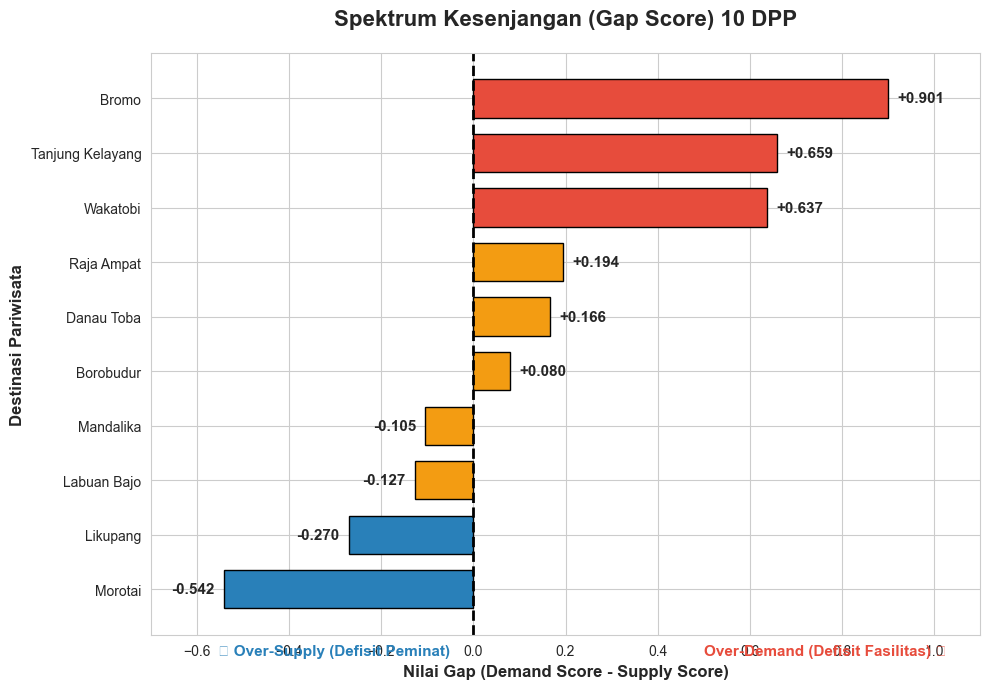

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. MEMBACA DATA
# =========================================================
print("📊 Membaca data final untuk Bar Chart Gap Analysis...")
df = pd.read_csv('final_dashboard_dataset_K3.csv')

# Mengurutkan data berdasarkan Gap_Analysis dari terkecil ke terbesar 
# (agar saat di-plot horizontal, nilai tertinggi berada di posisi paling atas)
df_sorted = df.sort_values(by='Gap_Analysis', ascending=True).reset_index(drop=True)

# =========================================================
# 2. PENGATURAN WARNA OTOMATIS
# =========================================================
# Warna Merah untuk Gap > 0.2 (Over-Demand)
# Warna Kuning/Oranye untuk Gap sekitar 0 (Mendekati seimbang)
# Warna Biru untuk Gap < -0.2 (Over-Supply)
colors = []
for val in df_sorted['Gap_Analysis']:
    if val > 0.2:
        colors.append('#e74c3c') # Merah
    elif val < -0.2:
        colors.append('#2980b9') # Biru
    else:
        colors.append('#f39c12') # Kuning/Oranye

# =========================================================
# 3. MEMBUAT HORIZONTAL BAR CHART
# =========================================================
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# Plot batang horizontal
bars = plt.barh(df_sorted['DPP'], df_sorted['Gap_Analysis'], color=colors, edgecolor='black', height=0.7)

# Menambahkan Garis Keseimbangan (Titik 0) di tengah
plt.axvline(x=0, color='black', linewidth=2, linestyle='--')

# =========================================================
# 4. MENAMBAHKAN LABEL ANGKA DI UJUNG BATANG
# =========================================================
for bar in bars:
    xval = bar.get_width()
    # Jika positif, taruh teks sedikit di sebelah kanan batang
    if xval > 0:
        plt.text(xval + 0.02, bar.get_y() + bar.get_height()/2, f'+{xval:.3f}', 
                 va='center', ha='left', fontsize=11, fontweight='bold')
    # Jika negatif, taruh teks sedikit di sebelah kiri batang
    else:
        plt.text(xval - 0.02, bar.get_y() + bar.get_height()/2, f'{xval:.3f}', 
                 va='center', ha='right', fontsize=11, fontweight='bold')

# =========================================================
# 5. KOSMETIK & FORMATTING
# =========================================================
plt.title('Spektrum Kesenjangan (Gap Score) 10 DPP', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nilai Gap (Demand Score - Supply Score)', fontsize=12, fontweight='bold')
plt.ylabel('Destinasi Pariwisata', fontsize=12, fontweight='bold')

# Melonggarkan sumbu X agar teks angka tidak terpotong
plt.xlim(-0.7, 1.1)

# Menambahkan teks petunjuk di area grafik
plt.text(0.5, -1.2, 'Over-Demand (Defisit Fasilitas) ➔', color='#e74c3c', fontsize=11, fontweight='bold', ha='left')
plt.text(-0.05, -1.2, '🡨 Over-Supply (Defisit Peminat)', color='#2980b9', fontsize=11, fontweight='bold', ha='right')

# Menyimpan hasil ke file PNG resolusi tinggi
output_file = 'BarChart_Gap_Spektrum.png'
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches='tight')

print(f"✅ GRAFIK SELESAI! Tersimpan sebagai: '{output_file}'")
plt.show()

📊 Membaca data final untuk Bar Chart Gap Analysis...


C:\Users\User\AppData\Local\Temp\ipykernel_20948\945847503.py:70: UserWarning: Glyph 129128 (\N{WIDE-HEADED LEFTWARDS BARB ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20948\945847503.py:70: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20948\945847503.py:71: UserWarning: Glyph 129128 (\N{WIDE-HEADED LEFTWARDS BARB ARROW}) missing from font(s) Arial.
  plt.savefig(output_file, dpi=300, bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_20948\945847503.py:71: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.savefig(output_file, dpi=300, bbox_inches='tight')


✅ GRAFIK SELESAI! Tersimpan sebagai: 'BarChart_Gap_Spektrum_Final.png'


c:\Users\User\Desktop\KULIAH\SEMESTER 6\SDC\kemenpar\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129128 (\N{WIDE-HEADED LEFTWARDS BARB ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\Desktop\KULIAH\SEMESTER 6\SDC\kemenpar\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


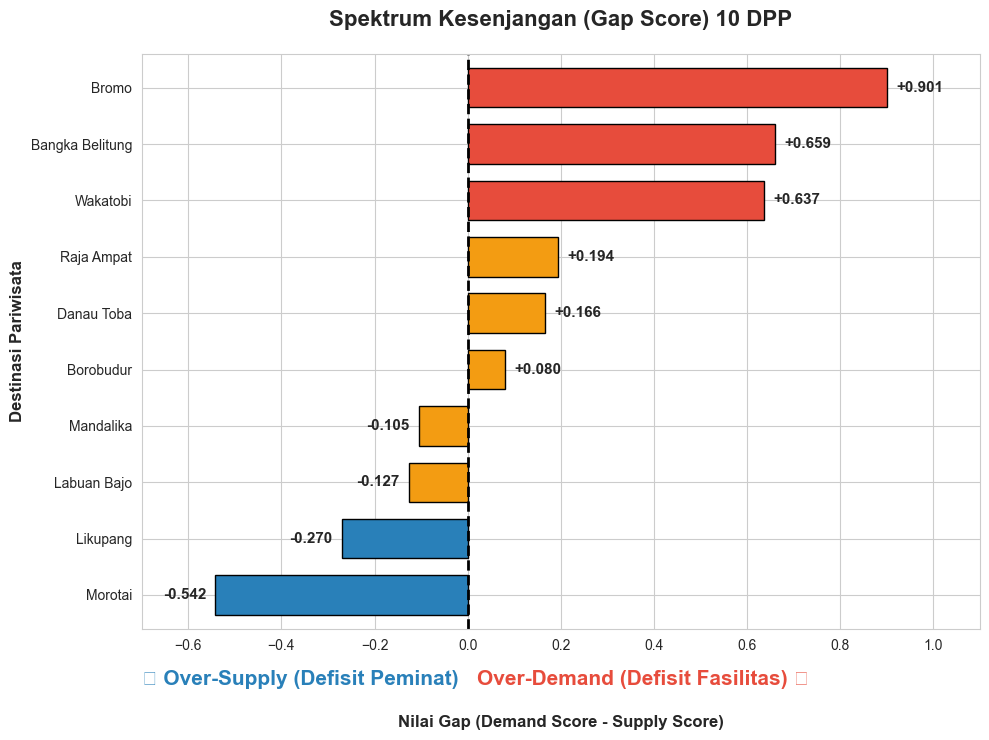

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. MEMBACA DATA
# =========================================================
print("📊 Membaca data final untuk Bar Chart Gap Analysis...")
df = pd.read_csv('final_dashboard_dataset_K3.csv')

# Mengurutkan data berdasarkan Gap_Analysis dari terkecil ke terbesar 
df_sorted = df.sort_values(by='Gap_Analysis', ascending=True).reset_index(drop=True)

# =========================================================
# 2. PENGATURAN WARNA OTOMATIS
# =========================================================
colors = []
for val in df_sorted['Gap_Analysis']:
    if val > 0.2:
        colors.append('#e74c3c') # Merah
    elif val < -0.2:
        colors.append('#2980b9') # Biru
    else:
        colors.append('#f39c12') # Kuning/Oranye

# =========================================================
# 3. MEMBUAT HORIZONTAL BAR CHART
# =========================================================
plt.figure(figsize=(10, 7.5)) 
sns.set_style("whitegrid")

# Plot batang horizontal
bars = plt.barh(df_sorted['DPP'], df_sorted['Gap_Analysis'], color=colors, edgecolor='black', height=0.7)

# Menambahkan Garis Keseimbangan (Titik 0) di tengah
plt.axvline(x=0, color='black', linewidth=2, linestyle='--')

# =========================================================
# 4. MENAMBAHKAN LABEL ANGKA DI UJUNG BATANG
# =========================================================
for bar in bars:
    xval = bar.get_width()
    if xval > 0:
        plt.text(xval + 0.02, bar.get_y() + bar.get_height()/2, f'+{xval:.3f}', 
                 va='center', ha='left', fontsize=11, fontweight='bold')
    else:
        plt.text(xval - 0.02, bar.get_y() + bar.get_height()/2, f'{xval:.3f}', 
                 va='center', ha='right', fontsize=11, fontweight='bold')

# =========================================================
# 5. KOSMETIK & FORMATTING (POSISI TEKS DI LUAR KOTAK)
# =========================================================
plt.title('Spektrum Kesenjangan (Gap Score) 10 DPP', fontsize=16, fontweight='bold', pad=20)

# Mendorong judul sumbu X jauh ke bawah (labelpad=45) untuk memberi ruang kosong
plt.xlabel('Nilai Gap (Demand Score - Supply Score)', fontsize=12, fontweight='bold', labelpad=45)
plt.ylabel('Destinasi Pariwisata', fontsize=12, fontweight='bold')

plt.xlim(-0.7, 1.1)
# Mengembalikan kotak grafik agar rapat dan proporsional dengan batang
plt.ylim(-0.6, 9.6) 

# KUNCI UTAMA: clip_on=False memungkinkan teks digambar di luar kotak (di antara angka dan label)
# Ukuran diperbesar menjadi fontsize=15
plt.text(-0.02, -1.6, '🡨 Over-Supply (Defisit Peminat)', color='#2980b9', fontsize=15, fontweight='bold', ha='right', clip_on=False)
plt.text(0.02, -1.6, 'Over-Demand (Defisit Fasilitas) ➔', color='#e74c3c', fontsize=15, fontweight='bold', ha='left', clip_on=False)

# Menyimpan hasil ke file PNG
output_file = 'BarChart_Gap_Spektrum_Final.png'
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches='tight')

print(f"✅ GRAFIK SELESAI! Tersimpan sebagai: '{output_file}'")
plt.show()

In [8]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import numpy as np

print("🗺️ Memulai pembuatan Peta Sebaran Fasilitas Super Map (Filtered)...")

# =========================================================
# FUNGSI MENGHITUNG JARAK (HAVERSINE FORMULA)
# =========================================================
def haversine_distance(lat1, lon1, lat2, lon2):
    """Menghitung jarak dalam kilometer antara 2 titik koordinat bumi."""
    R = 6371.0 # Radius bumi dalam km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# Kamus Koordinat Pusat 10 DPP
dpp_coords = {
    'Borobudur': [-7.6079, 110.2038], 'Bromo': [-7.9425, 112.9530],
    'Danau Toba': [2.6166, 98.7666], 'Labuan Bajo': [-8.4964, 119.8877],
    'Likupang': [1.6826, 125.0566], 'Mandalika': [-8.8950, 116.2950],
    'Morotai': [2.0401, 128.2930], 'Raja Ampat': [-0.2319, 130.5136],
    'Tanjung Kelayang': [-2.5594, 107.6710], 'Wakatobi': [-5.3166, 123.5833]
}

# =========================================================
# 1. INISIALISASI PETA DASAR & LAYER CONTROL
# =========================================================
peta_fasilitas = folium.Map(location=[-0.7893, 113.9213], zoom_start=5, tiles='CartoDB positron')

fg_bandara = folium.FeatureGroup(name='✈️ Bandara (Radius 100km)')
fg_pelabuhan = folium.FeatureGroup(name='🚢 Pelabuhan (10 DPP)')

# MarkerCluster agar titik ratusan hotel/restoran tidak bikin lag
fg_hotel = folium.FeatureGroup(name='🏨 Hotel & Akomodasi')
mc_hotel = MarkerCluster().add_to(fg_hotel)

fg_restoran = folium.FeatureGroup(name='🍽️ Restoran & Kuliner')
mc_restoran = MarkerCluster().add_to(fg_restoran)

fg_atraksi = folium.FeatureGroup(name='📸 Atraksi Wisata')
mc_atraksi = MarkerCluster().add_to(fg_atraksi)

# =========================================================
# 2. FILTER & PLOT BANDARA (RADIUS 100 KM DARI DPP)
# =========================================================
try:
    print("Memproses dan memfilter data Bandara...")
    df_bandara = pd.read_csv('master_bandara_indonesia.csv').dropna(subset=['latitude_deg', 'longitude_deg'])
    
    batas_radius_km = 100.0 # Hanya ambil bandara max 100km dari DPP
    
    for _, row in df_bandara.iterrows():
        b_lat, b_lon = row['latitude_deg'], row['longitude_deg']
        
        # Cek apakah bandara ini dekat dengan salah satu dari 10 DPP
        is_near_dpp = False
        for dpp_name, coords in dpp_coords.items():
            dist = haversine_distance(b_lat, b_lon, coords[0], coords[1])
            if dist <= batas_radius_km:
                is_near_dpp = True
                break # Lolos filter jika masuk radius
                
        if is_near_dpp:
            folium.Marker(
                location=[b_lat, b_lon],
                popup=folium.Popup(f"<b>Bandara:</b><br>{row.get('name', 'Unknown')}", max_width=250),
                icon=folium.Icon(color='black', icon='plane', prefix='fa')
            ).add_to(fg_bandara)
            
except Exception as e:
    print("Gagal memuat bandara:", e)

# =========================================================
# 3. PLOT PELABUHAN
# =========================================================
try:
    print("Memproses data Pelabuhan...")
    df_pelabuhan = pd.read_csv('master_pelabuhan_10dpp_mengerucut.csv').dropna(subset=['Latitude', 'Longitude'])
    for _, row in df_pelabuhan.iterrows():
        folium.Marker(
            location=[row['Latitude'], row['Longitude']],
            popup=folium.Popup(f"<b>Pelabuhan:</b><br>{row.get('Nama_Pelabuhan', 'Unknown')}", max_width=250),
            icon=folium.Icon(color='cadetblue', icon='ship', prefix='fa')
        ).add_to(fg_pelabuhan)
except Exception as e:
    print("Gagal memuat pelabuhan:", e)

# =========================================================
# 4. PLOT HOTEL, RESTORAN, & ATRAKSI
# =========================================================
try:
    print("Memproses data Hotel...")
    df_hotel = pd.read_csv('hotel_with_coordinates_baru.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_hotel.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=folium.Popup(f"<b>Hotel:</b> {row.get('hotel_name', 'Unknown')}", max_width=250),
            icon=folium.Icon(color='blue', icon='bed', prefix='fa')
        ).add_to(mc_hotel)
except Exception as e:
    print("Gagal memuat hotel:", e)

try:
    print("Memproses data Restoran...")
    df_resto = pd.read_csv('restoran_indonesia.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_resto.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=folium.Popup(f"<b>Resto:</b> {row.get('place_name', 'Unknown')}", max_width=250),
            icon=folium.Icon(color='orange', icon='cutlery', prefix='fa')
        ).add_to(mc_restoran)
except Exception as e:
    print("Gagal memuat restoran:", e)

try:
    print("Memproses data Atraksi...")
    df_atraksi = pd.read_csv('atraksi_indonesia.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_atraksi.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=folium.Popup(f"<b>Atraksi:</b> {row.get('place_name', 'Unknown')}", max_width=250),
            icon=folium.Icon(color='purple', icon='camera', prefix='fa')
        ).add_to(mc_atraksi)
except Exception as e:
    print("Gagal memuat atraksi:", e)

# =========================================================
# 5. MENGGABUNGKAN DAN MENYIMPAN PETA
# =========================================================
print("Menyatukan layer dan menyimpan Peta...")
peta_fasilitas.add_child(fg_bandara)
peta_fasilitas.add_child(fg_pelabuhan)
peta_fasilitas.add_child(fg_hotel)
peta_fasilitas.add_child(fg_restoran)
peta_fasilitas.add_child(fg_atraksi)

folium.LayerControl(position='topright').add_to(peta_fasilitas)

output_map_fasilitas = 'Peta_SuperMap_Filtered_Kemenpar.html'
peta_fasilitas.save(output_map_fasilitas)

print(f"\n✅ SUPER MAP SELESAI! Peta tersimpan di: '{output_map_fasilitas}'")

🗺️ Memulai pembuatan Peta Sebaran Fasilitas Super Map (Filtered)...
Memproses dan memfilter data Bandara...
Memproses data Pelabuhan...
Memproses data Hotel...
Memproses data Restoran...
Memproses data Atraksi...
Menyatukan layer dan menyimpan Peta...

✅ SUPER MAP SELESAI! Peta tersimpan di: 'Peta_SuperMap_Filtered_Kemenpar.html'


In [9]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import numpy as np

print("🗺️ Memulai pembuatan Peta Sebaran Fasilitas Super Map (Lengkap dengan 10 DPP)...")

# =========================================================
# FUNGSI MENGHITUNG JARAK (HAVERSINE FORMULA)
# =========================================================
def haversine_distance(lat1, lon1, lat2, lon2):
    """Menghitung jarak dalam kilometer antara 2 titik koordinat bumi."""
    R = 6371.0 # Radius bumi dalam km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# Kamus Koordinat Pusat 10 DPP
dpp_coords = {
    'Borobudur': [-7.6079, 110.2038], 'Bromo': [-7.9425, 112.9530],
    'Danau Toba': [2.6166, 98.7666], 'Labuan Bajo': [-8.4964, 119.8877],
    'Likupang': [1.6826, 125.0566], 'Mandalika': [-8.8950, 116.2950],
    'Morotai': [2.0401, 128.2930], 'Raja Ampat': [-0.2319, 130.5136],
    'Tanjung Kelayang': [-2.5594, 107.6710], 'Wakatobi': [-5.3166, 123.5833]
}

# =========================================================
# 1. INISIALISASI PETA DASAR & LAYER CONTROL
# =========================================================
peta_fasilitas = folium.Map(location=[-0.7893, 113.9213], zoom_start=5, tiles='CartoDB positron')

# Layer untuk 10 DPP (Paling Penting)
fg_dpp = folium.FeatureGroup(name='🌟 10 Destinasi Prioritas (DPP)')

fg_bandara = folium.FeatureGroup(name='✈️ Bandara (Radius 100km)')
fg_pelabuhan = folium.FeatureGroup(name='🚢 Pelabuhan (10 DPP)')

# MarkerCluster agar titik ratusan hotel/restoran tidak bikin lag
fg_hotel = folium.FeatureGroup(name='🏨 Hotel & Akomodasi')
mc_hotel = MarkerCluster().add_to(fg_hotel)

fg_restoran = folium.FeatureGroup(name='🍽️ Restoran & Kuliner')
mc_restoran = MarkerCluster().add_to(fg_restoran)

fg_atraksi = folium.FeatureGroup(name='📸 Atraksi Wisata')
mc_atraksi = MarkerCluster().add_to(fg_atraksi)


# =========================================================
# 2. PLOT 10 TITIK DPP (BERDASARKAN KLASTER)
# =========================================================
try:
    print("Memproses titik 10 Destinasi Prioritas...")
    df_final_k3 = pd.read_csv('final_dashboard_dataset_K3.csv')
    warna_klaster = {0: 'red', 1: 'green', 2: 'blue'}
    label_klaster = {0: 'Zona Defisit Infrastruktur', 1: 'Zona Mapan Premium', 2: 'Zona Defisit Peminat'}
    
    for _, row in df_final_k3.iterrows():
        nama_dpp = row['DPP']
        if nama_dpp in dpp_coords:
            lat, lon = dpp_coords[nama_dpp]
            cluster_id = int(row['Cluster_K3'])
            warna = warna_klaster.get(cluster_id, 'gray')
            nama_label = label_klaster.get(cluster_id, 'Unknown')
            
            popup_text = f"""
            <div style='min-width: 200px;'>
                <h4 style='margin-bottom:5px;'>🌟 <b>{nama_dpp}</b></h4>
                <b>Kategori:</b> {nama_label}<br>
                <b>Gap Score:</b> {row['Gap_Analysis']:.3f}<br>
                <b>Demand:</b> {row['Demand_Score']:.3f} | <b>Supply:</b> {row['Supply_Score']:.3f}
            </div>
            """
            
            folium.Marker(
                location=[lat, lon],
                popup=folium.Popup(popup_text, max_width=300),
                tooltip=f"Lokasi Pusat: {nama_dpp}",
                icon=folium.Icon(color=warna, icon='star', prefix='fa')
            ).add_to(fg_dpp)
except Exception as e:
    print("Gagal memuat titik 10 DPP:", e)


# =========================================================
# 3. FILTER & PLOT BANDARA (RADIUS 100 KM DARI DPP)
# =========================================================
try:
    print("Memproses dan memfilter data Bandara...")
    df_bandara = pd.read_csv('master_bandara_indonesia.csv').dropna(subset=['latitude_deg', 'longitude_deg'])
    batas_radius_km = 100.0 
    for _, row in df_bandara.iterrows():
        b_lat, b_lon = row['latitude_deg'], row['longitude_deg']
        is_near_dpp = any(haversine_distance(b_lat, b_lon, c[0], c[1]) <= batas_radius_km for c in dpp_coords.values())
        if is_near_dpp:
            folium.Marker(
                location=[b_lat, b_lon],
                popup=folium.Popup(f"<b>Bandara:</b><br>{row.get('name', 'Unknown')}", max_width=250),
                icon=folium.Icon(color='black', icon='plane', prefix='fa')
            ).add_to(fg_bandara)
except Exception as e:
    print("Gagal memuat bandara:", e)


# =========================================================
# 4. PLOT PELABUHAN
# =========================================================
try:
    print("Memproses data Pelabuhan...")
    df_pelabuhan = pd.read_csv('master_pelabuhan_10dpp_mengerucut.csv').dropna(subset=['Latitude', 'Longitude'])
    for _, row in df_pelabuhan.iterrows():
        folium.Marker(
            location=[row['Latitude'], row['Longitude']],
            popup=folium.Popup(f"<b>Pelabuhan:</b><br>{row.get('Nama_Pelabuhan', 'Unknown')}", max_width=250),
            icon=folium.Icon(color='cadetblue', icon='ship', prefix='fa')
        ).add_to(fg_pelabuhan)
except Exception as e:
    print("Gagal memuat pelabuhan:", e)


# =========================================================
# 5. PLOT HOTEL, RESTORAN, & ATRAKSI
# =========================================================
try:
    print("Memproses data Hotel...")
    df_hotel = pd.read_csv('hotel_with_coordinates_baru.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_hotel.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=folium.Popup(f"<b>Hotel:</b> {row.get('hotel_name', 'Unknown')}", max_width=250),
            icon=folium.Icon(color='blue', icon='bed', prefix='fa')
        ).add_to(mc_hotel)
except Exception as e:
    print("Gagal memuat hotel:", e)

try:
    print("Memproses data Restoran...")
    df_resto = pd.read_csv('restoran_indonesia.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_resto.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=folium.Popup(f"<b>Resto:</b> {row.get('place_name', 'Unknown')}", max_width=250),
            icon=folium.Icon(color='orange', icon='cutlery', prefix='fa')
        ).add_to(mc_restoran)
except Exception as e:
    print("Gagal memuat restoran:", e)

try:
    print("Memproses data Atraksi...")
    df_atraksi = pd.read_csv('atraksi_indonesia.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_atraksi.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=folium.Popup(f"<b>Atraksi:</b> {row.get('place_name', 'Unknown')}", max_width=250),
            icon=folium.Icon(color='purple', icon='camera', prefix='fa')
        ).add_to(mc_atraksi)
except Exception as e:
    print("Gagal memuat atraksi:", e)


# =========================================================
# 6. MENGGABUNGKAN DAN MENYIMPAN PETA
# =========================================================
print("Menyatukan layer dan menyimpan Peta...")
# Tambahkan fg_dpp paling akhir agar posisinya berada di layer teratas (tidak tertutup titik lain)
peta_fasilitas.add_child(fg_bandara)
peta_fasilitas.add_child(fg_pelabuhan)
peta_fasilitas.add_child(fg_hotel)
peta_fasilitas.add_child(fg_restoran)
peta_fasilitas.add_child(fg_atraksi)
peta_fasilitas.add_child(fg_dpp) 

# Layer control untuk on/off
folium.LayerControl(position='topright').add_to(peta_fasilitas)

output_map_fasilitas = 'Peta_SuperMap_Lengkap_Kemenpar.html'
peta_fasilitas.save(output_map_fasilitas)

print(f"\n✅ SUPER MAP SELESAI SEMPURNA! Peta tersimpan di: '{output_map_fasilitas}'")

🗺️ Memulai pembuatan Peta Sebaran Fasilitas Super Map (Lengkap dengan 10 DPP)...
Memproses titik 10 Destinasi Prioritas...
Memproses dan memfilter data Bandara...
Memproses data Pelabuhan...
Memproses data Hotel...
Memproses data Restoran...
Memproses data Atraksi...
Menyatukan layer dan menyimpan Peta...

✅ SUPER MAP SELESAI SEMPURNA! Peta tersimpan di: 'Peta_SuperMap_Lengkap_Kemenpar.html'


In [13]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import numpy as np

print("🗺️ Memulai pembuatan Peta Sebaran Fasilitas Super Map (Dengan Legenda)...")

# =========================================================
# FUNGSI MENGHITUNG JARAK (HAVERSINE FORMULA)
# =========================================================
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

dpp_coords = {
    'Borobudur': [-7.6079, 110.2038], 'Bromo': [-7.9425, 112.9530],
    'Danau Toba': [2.6166, 98.7666], 'Labuan Bajo': [-8.4964, 119.8877],
    'Likupang': [1.6826, 125.0566], 'Mandalika': [-8.8950, 116.2950],
    'Morotai': [2.0401, 128.2930], 'Raja Ampat': [-0.2319, 130.5136],
    'Tanjung Kelayang': [-2.5594, 107.6710], 'Wakatobi': [-5.3166, 123.5833]
}

# =========================================================
# 1. INISIALISASI PETA DASAR
# =========================================================
peta_fasilitas = folium.Map(location=[-0.7893, 113.9213], zoom_start=5, tiles='CartoDB positron')

fg_dpp = folium.FeatureGroup(name='🌟 10 Destinasi Prioritas (DPP)')
fg_bandara = folium.FeatureGroup(name='✈️ Bandara (Radius 100km)')
fg_pelabuhan = folium.FeatureGroup(name='🚢 Pelabuhan (10 DPP)')

mc_hotel = MarkerCluster(name='🏨 Hotel & Akomodasi').add_to(peta_fasilitas)
mc_restoran = MarkerCluster(name='🍽️ Restoran & Kuliner').add_to(peta_fasilitas)
mc_atraksi = MarkerCluster(name='📸 Atraksi Wisata').add_to(peta_fasilitas)

# =========================================================
# 2. PLOT 10 TITIK DPP (BERDASARKAN KLASTER)
# =========================================================
try:
    df_final_k3 = pd.read_csv('final_dashboard_dataset_K3.csv')
    warna_klaster = {0: 'red', 1: 'green', 2: 'blue'}
    label_klaster = {0: 'Zona Defisit Infrastruktur', 1: 'Zona Mapan Premium', 2: 'Zona Defisit Peminat'}
    
    for _, row in df_final_k3.iterrows():
        nama_dpp = row['DPP']
        if nama_dpp in dpp_coords:
            lat, lon = dpp_coords[nama_dpp]
            cluster_id = int(row['Cluster_K3'])
            warna = warna_klaster.get(cluster_id, 'gray')
            nama_label = label_klaster.get(cluster_id, 'Unknown')
            
            popup_text = f"""
            <div style='min-width: 200px;'>
                <h4 style='margin-bottom:5px;'>🌟 <b>{nama_dpp}</b></h4>
                <b>Kategori:</b> {nama_label}<br>
                <b>Gap Score:</b> {row['Gap_Analysis']:.3f}<br>
                <b>Demand:</b> {row['Demand_Score']:.3f} | <b>Supply:</b> {row['Supply_Score']:.3f}
            </div>
            """
            
            folium.Marker(
                location=[lat, lon], popup=folium.Popup(popup_text, max_width=300),
                tooltip=f"Pusat: {nama_dpp}", icon=folium.Icon(color=warna, icon='star', prefix='fa')
            ).add_to(fg_dpp)
except Exception as e:
    print("Gagal memuat titik 10 DPP:", e)

# =========================================================
# 3. PLOT BANDARA, PELABUHAN, HOTEL, RESTO, ATRAKSI
# =========================================================
try:
    df_bandara = pd.read_csv('master_bandara_indonesia.csv').dropna(subset=['latitude_deg', 'longitude_deg'])
    for _, row in df_bandara.iterrows():
        b_lat, b_lon = row['latitude_deg'], row['longitude_deg']
        if any(haversine_distance(b_lat, b_lon, c[0], c[1]) <= 100.0 for c in dpp_coords.values()):
            folium.Marker(
                location=[b_lat, b_lon], popup=f"<b>Bandara:</b><br>{row.get('name', 'Unknown')}",
                icon=folium.Icon(color='black', icon='plane', prefix='fa')
            ).add_to(fg_bandara)
except: pass

try:
    df_pelabuhan = pd.read_csv('master_pelabuhan_10dpp_mengerucut.csv').dropna(subset=['Latitude', 'Longitude'])
    for _, row in df_pelabuhan.iterrows():
        folium.Marker(
            location=[row['Latitude'], row['Longitude']], popup=f"<b>Pelabuhan:</b><br>{row.get('Nama_Pelabuhan', 'Unknown')}",
            icon=folium.Icon(color='cadetblue', icon='ship', prefix='fa')
        ).add_to(fg_pelabuhan)
except: pass

try:
    df_hotel = pd.read_csv('hotel_with_coordinates_baru.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_hotel.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']], popup=f"<b>Hotel:</b> {row.get('hotel_name', 'Unknown')}",
            icon=folium.Icon(color='blue', icon='bed', prefix='fa')
        ).add_to(mc_hotel)
except: pass

try:
    df_resto = pd.read_csv('restoran_indonesia.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_resto.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']], popup=f"<b>Resto:</b> {row.get('place_name', 'Unknown')}",
            icon=folium.Icon(color='orange', icon='cutlery', prefix='fa')
        ).add_to(mc_restoran)
except: pass

try:
    df_atraksi = pd.read_csv('atraksi_indonesia.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_atraksi.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']], popup=f"<b>Atraksi:</b> {row.get('place_name', 'Unknown')}",
            icon=folium.Icon(color='purple', icon='camera', prefix='fa')
        ).add_to(mc_atraksi)
except: pass

# =========================================================
# 4. MENYUNTIKKAN KOTAK LEGENDA (INFORMASI TITIK)
# =========================================================
print("Menambahkan Kotak Legenda Informasi...")

legenda_html = '''
<div style="
    position: fixed; 
    bottom: 30px; left: 30px; width: 280px; 
    background-color: white; border: 2px solid grey; z-index: 9999; 
    font-size: 13px; padding: 12px; border-radius: 8px; 
    box-shadow: 4px 4px 6px rgba(0,0,0,0.3); font-family: Arial, sans-serif;
    ">
    <h4 style="margin-top: 0; margin-bottom: 8px; text-align: center;"><b>📌 Legenda Peta</b></h4>
    <hr style="margin: 5px 0;">
    <b>Titik 10 DPP (Hasil K-Means):</b><br>
    <i class="fa fa-star fa-lg" style="color:red; margin: 4px 5px;"></i> Zona Akselerasi Infrastruktur<br>
    <i class="fa fa-star fa-lg" style="color:green; margin: 4px 5px;"></i> Zona Pengendalian Kualitas<br>
    <i class="fa fa-star fa-lg" style="color:blue; margin: 4px 5px;"></i> Zona Aktivasi Promosi<br>
    <hr style="margin: 8px 0;">
    <b>Fasilitas Fisik (Supply):</b><br>
    <i class="fa fa-plane fa-lg" style="color:black; margin: 4px 5px;"></i> Bandara Terdekat<br>
    <i class="fa fa-ship fa-lg" style="color:cadetblue; margin: 4px 5px;"></i> Pelabuhan / Dermaga<br>
    <i class="fa fa-bed fa-lg" style="color:blue; margin: 4px 5px;"></i> Akomodasi / Hotel<br>
    <i class="fa fa-cutlery fa-lg" style="color:orange; margin: 4px 5px;"></i> Restoran / Kuliner<br>
    <i class="fa fa-camera fa-lg" style="color:purple; margin: 4px 5px;"></i> Atraksi Wisata<br>
    <hr style="margin: 8px 0;">
    <span style="font-size:11px; color:gray;"><i>*Gunakan tombol di pojok kanan atas peta untuk menyaring kategori (Filter Layer)</i></span>
</div>
'''

# Memasukkan elemen HTML langsung ke dalam peta
peta_fasilitas.get_root().html.add_child(folium.Element(legenda_html))


# =========================================================
# 5. MENGGABUNGKAN DAN MENYIMPAN PETA
# =========================================================
print("Menyatukan layer dan menyimpan Peta Final...")
peta_fasilitas.add_child(fg_bandara)
peta_fasilitas.add_child(fg_pelabuhan)
peta_fasilitas.add_child(fg_dpp) 

folium.LayerControl(position='topright').add_to(peta_fasilitas)

output_map_fasilitas = 'Peta_SuperMap_Lengkap_Dengan_Legenda.html'
peta_fasilitas.save(output_map_fasilitas)

print(f"\n✅ SUPER MAP SELESAI SEMPURNA! Peta tersimpan di: '{output_map_fasilitas}'")

🗺️ Memulai pembuatan Peta Sebaran Fasilitas Super Map (Dengan Legenda)...
Menambahkan Kotak Legenda Informasi...
Menyatukan layer dan menyimpan Peta Final...

✅ SUPER MAP SELESAI SEMPURNA! Peta tersimpan di: 'Peta_SuperMap_Lengkap_Dengan_Legenda.html'


In [4]:
import pandas as pd
import folium
import numpy as np

print("🗺️ Memulai pembuatan Peta Sebaran Fasilitas Super Map (Ikon Tampil Semua)...")

# =========================================================
# FUNGSI MENGHITUNG JARAK (HAVERSINE FORMULA)
# =========================================================
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

dpp_coords = {
    'Borobudur': [-7.6079, 110.2038], 'Bromo': [-7.9425, 112.9530],
    'Danau Toba': [2.6166, 98.7666], 'Labuan Bajo': [-8.4964, 119.8877],
    'Likupang': [1.6826, 125.0566], 'Mandalika': [-8.8950, 116.2950],
    'Morotai': [2.0401, 128.2930], 'Raja Ampat': [-0.2319, 130.5136],
    'Tanjung Kelayang': [-2.5594, 107.6710], 'Wakatobi': [-5.3166, 123.5833]
}

# =========================================================
# 1. INISIALISASI PETA DASAR
# =========================================================
peta_fasilitas = folium.Map(location=[-0.7893, 113.9213], zoom_start=5, tiles='CartoDB positron')

fg_dpp = folium.FeatureGroup(name='🌟 10 Destinasi Prioritas (DPP)')
fg_bandara = folium.FeatureGroup(name='✈️ Bandara (Radius 100km)')
fg_pelabuhan = folium.FeatureGroup(name='🚢 Pelabuhan (10 DPP)')

# [KUNCI PERUBAHAN]: Mengganti MarkerCluster menjadi FeatureGroup agar ikon tidak digabung
fg_hotel = folium.FeatureGroup(name='🏨 Hotel & Akomodasi')
fg_restoran = folium.FeatureGroup(name='🍽️ Restoran & Kuliner')
fg_atraksi = folium.FeatureGroup(name='📸 Atraksi Wisata')

# =========================================================
# 2. PLOT 10 TITIK DPP (BERDASARKAN KLASTER)
# =========================================================
try:
    df_final_k3 = pd.read_csv('final_dashboard_dataset_K3.csv')
    warna_klaster = {0: 'red', 1: 'green', 2: 'blue'}
    label_klaster = {0: 'Zona Defisit Infrastruktur', 1: 'Zona Mapan Premium', 2: 'Zona Defisit Peminat'}
    
    for _, row in df_final_k3.iterrows():
        nama_dpp = row['DPP']
        if nama_dpp in dpp_coords:
            lat, lon = dpp_coords[nama_dpp]
            cluster_id = int(row['Cluster_K3'])
            warna = warna_klaster.get(cluster_id, 'gray')
            nama_label = label_klaster.get(cluster_id, 'Unknown')
            
            popup_text = f"""
            <div style='min-width: 200px;'>
                <h4 style='margin-bottom:5px;'>🌟 <b>{nama_dpp}</b></h4>
                <b>Kategori:</b> {nama_label}<br>
                <b>Gap Score:</b> {row['Gap_Analysis']:.3f}<br>
                <b>Demand:</b> {row['Demand_Score']:.3f} | <b>Supply:</b> {row['Supply_Score']:.3f}
            </div>
            """
            
            folium.Marker(
                location=[lat, lon], popup=folium.Popup(popup_text, max_width=300),
                tooltip=f"Pusat: {nama_dpp}", icon=folium.Icon(color=warna, icon='star', prefix='fa')
            ).add_to(fg_dpp)
except Exception as e:
    print("Gagal memuat titik 10 DPP:", e)

# =========================================================
# 3. PLOT FASILITAS MENGGUNAKAN IKON STANDAR
# =========================================================
try:
    df_bandara = pd.read_csv('master_bandara_indonesia.csv').dropna(subset=['latitude_deg', 'longitude_deg'])
    for _, row in df_bandara.iterrows():
        b_lat, b_lon = row['latitude_deg'], row['longitude_deg']
        if any(haversine_distance(b_lat, b_lon, c[0], c[1]) <= 100.0 for c in dpp_coords.values()):
            folium.Marker(
                location=[b_lat, b_lon], popup=f"<b>Bandara:</b><br>{row.get('name', 'Unknown')}",
                icon=folium.Icon(color='black', icon='plane', prefix='fa')
            ).add_to(fg_bandara)
except: pass

try:
    df_pelabuhan = pd.read_csv('master_pelabuhan_10dpp_mengerucut.csv').dropna(subset=['Latitude', 'Longitude'])
    for _, row in df_pelabuhan.iterrows():
        folium.Marker(
            location=[row['Latitude'], row['Longitude']], popup=f"<b>Pelabuhan:</b><br>{row.get('Nama_Pelabuhan', 'Unknown')}",
            icon=folium.Icon(color='cadetblue', icon='ship', prefix='fa')
        ).add_to(fg_pelabuhan)
except: pass

try:
    df_hotel = pd.read_csv('hotel_with_coordinates_baru.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_hotel.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']], popup=f"<b>Hotel:</b> {row.get('hotel_name', 'Unknown')}",
            icon=folium.Icon(color='blue', icon='bed', prefix='fa')
        ).add_to(fg_hotel)
except: pass

try:
    df_resto = pd.read_csv('restoran_indonesia.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_resto.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']], popup=f"<b>Resto:</b> {row.get('place_name', 'Unknown')}",
            icon=folium.Icon(color='orange', icon='cutlery', prefix='fa')
        ).add_to(fg_restoran)
except: pass

try:
    df_atraksi = pd.read_csv('atraksi_indonesia.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_atraksi.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']], popup=f"<b>Atraksi:</b> {row.get('place_name', 'Unknown')}",
            icon=folium.Icon(color='purple', icon='camera', prefix='fa')
        ).add_to(fg_atraksi)
except: pass

# =========================================================
# 4. MENYUNTIKKAN KOTAK LEGENDA
# =========================================================
print("Menambahkan Kotak Legenda Informasi...")

legenda_html = '''
<div style="
    position: fixed; 
    bottom: 30px; left: 30px; width: 280px; 
    background-color: white; border: 2px solid grey; z-index: 9999; 
    font-size: 13px; padding: 12px; border-radius: 8px; 
    box-shadow: 4px 4px 6px rgba(0,0,0,0.3); font-family: Arial, sans-serif;
    ">
    <h4 style="margin-top: 0; margin-bottom: 8px; text-align: center;"><b>📌 Legenda Peta</b></h4>
    <hr style="margin: 5px 0;">
    <b>Titik 10 DPP (Hasil K-Means):</b><br>
    <i class="fa fa-star fa-lg" style="color:red; margin: 4px 5px;"></i> Zona Akselerasi Infrastruktur<br>
    <i class="fa fa-star fa-lg" style="color:green; margin: 4px 5px;"></i> Zona Pengendalian Kualitas<br>
    <i class="fa fa-star fa-lg" style="color:blue; margin: 4px 5px;"></i> Zona Aktivasi Promosi<br>
    <hr style="margin: 8px 0;">
    <b>Fasilitas Fisik (Supply):</b><br>
    <i class="fa fa-plane fa-lg" style="color:black; margin: 4px 5px;"></i> Bandara Terdekat<br>
    <i class="fa fa-ship fa-lg" style="color:cadetblue; margin: 4px 5px;"></i> Pelabuhan / Dermaga<br>
    <i class="fa fa-bed fa-lg" style="color:blue; margin: 4px 5px;"></i> Akomodasi / Hotel<br>
    <i class="fa fa-cutlery fa-lg" style="color:orange; margin: 4px 5px;"></i> Restoran / Kuliner<br>
    <i class="fa fa-camera fa-lg" style="color:purple; margin: 4px 5px;"></i> Atraksi Wisata<br>
    <hr style="margin: 8px 0;">
    <span style="font-size:11px; color:gray;"><i>*Gunakan tombol di pojok kanan atas peta untuk menyaring kategori (Filter Layer)</i></span>
</div>
'''

peta_fasilitas.get_root().html.add_child(folium.Element(legenda_html))

# =========================================================
# 5. MENGGABUNGKAN DAN MENYIMPAN PETA
# =========================================================
print("Menyatukan layer dan menyimpan Peta Final...")
peta_fasilitas.add_child(fg_hotel)
peta_fasilitas.add_child(fg_restoran)
peta_fasilitas.add_child(fg_atraksi)
peta_fasilitas.add_child(fg_bandara)
peta_fasilitas.add_child(fg_pelabuhan)
peta_fasilitas.add_child(fg_dpp) 

folium.LayerControl(position='topright').add_to(peta_fasilitas)

output_map_fasilitas = 'Peta_SuperMap_Ikon_Penuh.html'
peta_fasilitas.save(output_map_fasilitas)

print(f"\n✅ SUPER MAP SELESAI SEMPURNA! Peta tersimpan di: '{output_map_fasilitas}'")

🗺️ Memulai pembuatan Peta Sebaran Fasilitas Super Map (Ikon Tampil Semua)...
Menambahkan Kotak Legenda Informasi...
Menyatukan layer dan menyimpan Peta Final...

✅ SUPER MAP SELESAI SEMPURNA! Peta tersimpan di: 'Peta_SuperMap_Ikon_Penuh.html'


In [ ]:
import pandas as pd
import folium
import numpy as np

print("🗺️ Memulai pembuatan Peta Sebaran Fasilitas Super Map (Ikon Penuh + Data Cleaning)...")

# =========================================================
# FUNGSI MENGHITUNG JARAK (HAVERSINE FORMULA)
# =========================================================
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

dpp_coords = {
    'Borobudur': [-7.6079, 110.2038], 'Bromo': [-7.9425, 112.9530],
    'Danau Toba': [2.6166, 98.7666], 'Labuan Bajo': [-8.4964, 119.8877],
    'Likupang': [1.6826, 125.0566], 'Mandalika': [-8.8950, 116.2950],
    'Morotai': [2.0401, 128.2930], 'Raja Ampat': [-0.2319, 130.5136],
    'Tanjung Kelayang': [-2.5594, 107.6710], 'Wakatobi': [-5.3166, 123.5833]
}

# =========================================================
# 1. INISIALISASI PETA DASAR
# =========================================================
peta_fasilitas = folium.Map(location=[-0.7893, 113.9213], zoom_start=5, tiles='CartoDB positron')

fg_dpp = folium.FeatureGroup(name='🌟 10 Destinasi Prioritas (DPP)')
fg_bandara = folium.FeatureGroup(name='✈️ Bandara (Radius 100km)')
fg_pelabuhan = folium.FeatureGroup(name='🚢 Pelabuhan (10 DPP)')

fg_hotel = folium.FeatureGroup(name='🏨 Hotel & Akomodasi')
fg_restoran = folium.FeatureGroup(name='🍽️ Restoran & Kuliner')
fg_atraksi = folium.FeatureGroup(name='📸 Atraksi Wisata')

# =========================================================
# 2. PLOT 10 TITIK DPP (BERDASARKAN KLASTER)
# =========================================================
try:
    df_final_k3 = pd.read_csv('final_dashboard_dataset_K3.csv')
    warna_klaster = {0: 'red', 1: 'green', 2: 'blue'}
    label_klaster = {0: 'Zona Defisit Infrastruktur', 1: 'Zona Mapan Premium', 2: 'Zona Defisit Peminat'}
    
    for _, row in df_final_k3.iterrows():
        nama_dpp = row['DPP']
        if nama_dpp in dpp_coords:
            lat, lon = dpp_coords[nama_dpp]
            cluster_id = int(row['Cluster_K3'])
            warna = warna_klaster.get(cluster_id, 'gray')
            nama_label = label_klaster.get(cluster_id, 'Unknown')
            
            popup_text = f"""
            <div style='min-width: 200px;'>
                <h4 style='margin-bottom:5px;'>🌟 <b>{nama_dpp}</b></h4>
                <b>Kategori:</b> {nama_label}<br>
                <b>Gap Score:</b> {row['Gap_Analysis']:.3f}<br>
                <b>Demand:</b> {row['Demand_Score']:.3f} | <b>Supply:</b> {row['Supply_Score']:.3f}
            </div>
            """
            
            folium.Marker(
                location=[lat, lon], popup=folium.Popup(popup_text, max_width=300),
                tooltip=f"Pusat: {nama_dpp}", icon=folium.Icon(color=warna, icon='star', prefix='fa')
            ).add_to(fg_dpp)
except Exception as e:
    print("Gagal memuat titik 10 DPP:", e)

# =========================================================
# 3. PLOT FASILITAS MENGGUNAKAN IKON STANDAR
# =========================================================
try:
    df_bandara = pd.read_csv('master_bandara_indonesia.csv').dropna(subset=['latitude_deg', 'longitude_deg'])
    for _, row in df_bandara.iterrows():
        b_lat, b_lon = row['latitude_deg'], row['longitude_deg']
        if any(haversine_distance(b_lat, b_lon, c[0], c[1]) <= 100.0 for c in dpp_coords.values()):
            folium.Marker(
                location=[b_lat, b_lon], popup=f"<b>Bandara:</b><br>{row.get('name', 'Unknown')}",
                icon=folium.Icon(color='black', icon='plane', prefix='fa')
            ).add_to(fg_bandara)
except: pass

try:
    df_pelabuhan = pd.read_csv('master_pelabuhan_10dpp_mengerucut.csv').dropna(subset=['Latitude', 'Longitude'])
    for _, row in df_pelabuhan.iterrows():
        folium.Marker(
            location=[row['Latitude'], row['Longitude']], popup=f"<b>Pelabuhan:</b><br>{row.get('Nama_Pelabuhan', 'Unknown')}",
            icon=folium.Icon(color='cadetblue', icon='ship', prefix='fa')
        ).add_to(fg_pelabuhan)
except: pass

try:
    df_hotel = pd.read_csv('hotel_with_coordinates_baru.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_hotel.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']], popup=f"<b>Hotel:</b> {row.get('hotel_name', 'Unknown')}",
            icon=folium.Icon(color='blue', icon='bed', prefix='fa')
        ).add_to(fg_hotel)
except: pass

try:
    # [REVISI]: Membaca data resto dan langsung memfilter outlier/kesalahan scraping
    df_resto = pd.read_csv('restoran_indonesia.csv').dropna(subset=['latitude', 'longitude'])
    
    # Membuang nama resto yang merupakan error scraping
    nama_resto_error = ['Rumah makan raja muda', 'Raja ampat bollangi gowa']
    df_resto = df_resto[~df_resto['place_name'].str.contains('|'.join(nama_resto_error), case=False, na=False)]
    
    for _, row in df_resto.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']], popup=f"<b>Resto:</b> {row.get('place_name', 'Unknown')}",
            icon=folium.Icon(color='orange', icon='cutlery', prefix='fa')
        ).add_to(fg_restoran)
except Exception as e: 
    print("Error di bagian restoran:", e)

try:
    df_atraksi = pd.read_csv('atraksi_indonesia.csv').dropna(subset=['latitude', 'longitude'])
    for _, row in df_atraksi.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']], popup=f"<b>Atraksi:</b> {row.get('place_name', 'Unknown')}",
            icon=folium.Icon(color='purple', icon='camera', prefix='fa')
        ).add_to(fg_atraksi)
except: pass

# =========================================================
# 4. MENYUNTIKKAN KOTAK LEGENDA
# =========================================================
print("Menambahkan Kotak Legenda Informasi...")

legenda_html = '''
<div style="
    position: fixed; 
    bottom: 30px; left: 30px; width: 280px; 
    background-color: white; border: 2px solid grey; z-index: 9999; 
    font-size: 13px; padding: 12px; border-radius: 8px; 
    box-shadow: 4px 4px 6px rgba(0,0,0,0.3); font-family: Arial, sans-serif;
    ">
    <h4 style="margin-top: 0; margin-bottom: 8px; text-align: center;"><b>📌 Legenda Peta</b></h4>
    <hr style="margin: 5px 0;">
    <b>Titik 10 DPP (Hasil K-Means):</b><br>
    <i class="fa fa-star fa-lg" style="color:red; margin: 4px 5px;"></i> Zona Akselerasi Infrastruktur<br>
    <i class="fa fa-star fa-lg" style="color:green; margin: 4px 5px;"></i> Zona Pengendalian Kualitas<br>
    <i class="fa fa-star fa-lg" style="color:blue; margin: 4px 5px;"></i> Zona Aktivasi Promosi<br>
    <hr style="margin: 8px 0;">
    <b>Fasilitas Fisik (Supply):</b><br>
    <i class="fa fa-plane fa-lg" style="color:black; margin: 4px 5px;"></i> Bandara Terdekat<br>
    <i class="fa fa-ship fa-lg" style="color:cadetblue; margin: 4px 5px;"></i> Pelabuhan / Dermaga<br>
    <i class="fa fa-bed fa-lg" style="color:blue; margin: 4px 5px;"></i> Akomodasi / Hotel<br>
    <i class="fa fa-cutlery fa-lg" style="color:orange; margin: 4px 5px;"></i> Restoran / Kuliner<br>
    <i class="fa fa-camera fa-lg" style="color:purple; margin: 4px 5px;"></i> Atraksi Wisata<br>
    <hr style="margin: 8px 0;">
    <span style="font-size:11px; color:gray;"><i>*Gunakan tombol di pojok kanan atas peta untuk menyaring kategori (Filter Layer)</i></span>
</div>
'''

peta_fasilitas.get_root().html.add_child(folium.Element(legenda_html))

# =========================================================
# 5. MENGGABUNGKAN DAN MENYIMPAN PETA
# =========================================================
print("Menyatukan layer dan menyimpan Peta Final...")
peta_fasilitas.add_child(fg_hotel)
peta_fasilitas.add_child(fg_restoran)
peta_fasilitas.add_child(fg_atraksi)
peta_fasilitas.add_child(fg_bandara)
peta_fasilitas.add_child(fg_pelabuhan)
peta_fasilitas.add_child(fg_dpp) 

folium.LayerControl(position='topright').add_to(peta_fasilitas)

output_map_fasilitas = 'Peta_SuperMap_Ikon_Penuh_Cleaned.html'
peta_fasilitas.save(output_map_fasilitas)

print(f"\n✅ SUPER MAP SELESAI SEMPURNA! Peta tersimpan di: '{output_map_fasilitas}'")

🗺️ Memulai pembuatan Peta Sebaran Fasilitas Super Map (Ikon Penuh + Data Cleaning)...
Menambahkan Kotak Legenda Informasi...
Menyatukan layer dan menyimpan Peta Final...

✅ SUPER MAP SELESAI SEMPURNA! Peta tersimpan di: 'Peta_SuperMap_Ikon_Penuh_Cleaned.html'


: 

In [1]:
import pandas as pd
import folium

print("🗺️ Membuat Peta Nasional Bersih untuk Screenshot PPT...")

# Koordinat 10 DPP
dpp_coords = {
    'Borobudur': [-7.6079, 110.2038], 'Bromo': [-7.9425, 112.9530],
    'Danau Toba': [2.6166, 98.7666], 'Labuan Bajo': [-8.4964, 119.8877],
    'Likupang': [1.6826, 125.0566], 'Mandalika': [-8.8950, 116.2950],
    'Morotai': [2.0401, 128.2930], 'Raja Ampat': [-0.2319, 130.5136],
    'Tanjung Kelayang': [-2.5594, 107.6710], 'Wakatobi': [-5.3166, 123.5833]
}

# 1. Peta Dasar: CartoDB Positron (Bersih, Abu-abu, Tidak Bising)
peta_bersih = folium.Map(location=[-2.5, 118.0], zoom_start=5, tiles='CartoDB positron', zoom_control=False)

# 2. Plot HANYA 10 Titik DPP (Tanpa Hotel, Tanpa Resto)
df_final_k3 = pd.read_csv('final_dashboard_dataset_K3.csv')
warna_klaster = {0: 'red', 1: 'green', 2: 'blue'}

for _, row in df_final_k3.iterrows():
    nama_dpp = row['DPP']
    if nama_dpp in dpp_coords:
        lat, lon = dpp_coords[nama_dpp]
        cluster_id = int(row['Cluster_K3'])
        warna = warna_klaster.get(cluster_id, 'gray')
        
        # Gunakan CircleMarker yang besar dan mencolok (bukan ikon default Folium)
        folium.CircleMarker(
            location=[lat, lon],
            radius=12, # Ukuran titik diperbesar agar terlihat jelas saat di-screenshot
            color='black', # Garis tepi
            weight=2,
            fill=True,
            fill_color=warna,
            fill_opacity=0.9,
            tooltip=nama_dpp
        ).add_to(peta_bersih)

        # Menambahkan Label Teks Permanen di sebelah titik (Sangat Kemenpar-friendly!)
        folium.Marker(
            location=[lat + 0.5, lon], # Digeser sedikit ke atas
            icon=folium.DivIcon(html=f"<div style='font-size: 14pt; font-weight: bold; color: black; white-space: nowrap; text-shadow: 2px 2px 4px white;'>{nama_dpp}</div>")
        ).add_to(peta_bersih)

# Simpan untuk di-screenshot
output_map = 'Peta_PPT_Screenshot.html'
peta_bersih.save(output_map)
print(f"✅ Buka file '{output_map}', perbesar browser, dan ambil Screenshot untuk PPT Anda!")

🗺️ Membuat Peta Nasional Bersih untuk Screenshot PPT...
✅ Buka file 'Peta_PPT_Screenshot.html', perbesar browser, dan ambil Screenshot untuk PPT Anda!


📊 Membaca data final untuk visualisasi...
✅ GRAFIK SELESAI! Berhasil disimpan sebagai gambar resolusi tinggi: 'Scatter_Plot_Klaster_Kebijakan.png'


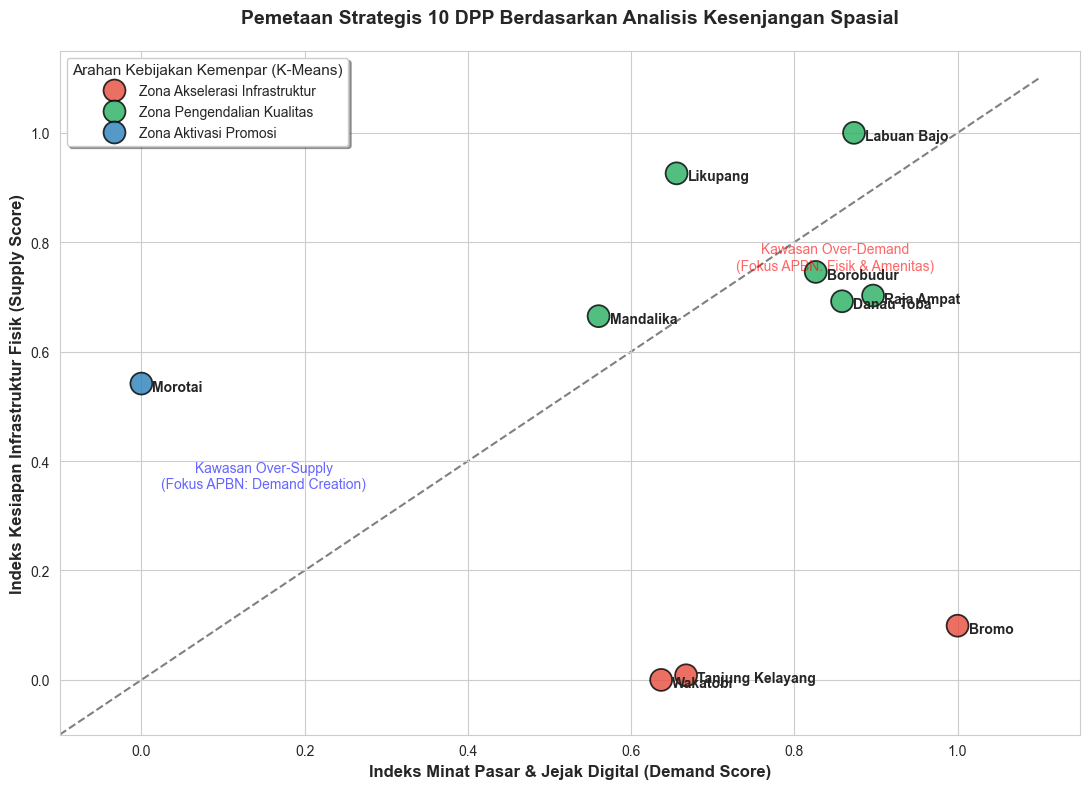

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. MEMBACA DATA FINAL
# =========================================================
print("📊 Membaca data final untuk visualisasi...")
df = pd.read_csv('final_dashboard_dataset_K3.csv')

# Memetakan angka klaster ke bahasa Birokrasi / Kementerian (Opsi 1)
label_mapping = {
    0: 'Zona Akselerasi Infrastruktur',
    1: 'Zona Pengendalian Kualitas',
    2: 'Zona Aktivasi Promosi'
}
df['Kategori_Klaster'] = df['Cluster_K3'].map(label_mapping)

# Menentukan warna khusus untuk tiap klaster
warna_klaster = {
    'Zona Akselerasi Infrastruktur': '#e74c3c', # Merah - Butuh tindakan fisik segera
    'Zona Pengendalian Kualitas': '#27ae60',    # Hijau - Ekosistem mapan/aman
    'Zona Aktivasi Promosi': '#2980b9'          # Biru - Butuh intervensi marketing
}

# =========================================================
# 2. KONFIGURASI KANVAS PLOT
# =========================================================
plt.figure(figsize=(11, 8))
sns.set_style("whitegrid")

# Membuat Scatter Plot utama
scatter = sns.scatterplot(
    data=df, 
    x='Demand_Score', 
    y='Supply_Score', 
    hue='Kategori_Klaster', 
    palette=warna_klaster,
    s=250, # Ukuran titik
    edgecolor='black',
    alpha=0.8
)

# =========================================================
# 3. MENAMBAHKAN GARIS KESEIMBANGAN (EQUILIBRIUM LINE)
# =========================================================
# Garis diagonal di mana Demand = Supply (Gap = 0)
plt.plot([-0.1, 1.1], [-0.1, 1.1], linestyle='--', color='gray', linewidth=1.5, zorder=0)

# Menambahkan teks petunjuk area Gap (Disesuaikan dengan konteks kebijakan)
plt.text(0.85, 0.75, 'Kawasan Over-Demand\n(Fokus APBN: Fisik & Amenitas)', color='red', alpha=0.6, fontsize=10, ha='center')
plt.text(0.15, 0.35, 'Kawasan Over-Supply\n(Fokus APBN: Demand Creation)', color='blue', alpha=0.6, fontsize=10, ha='center')

# =========================================================
# 4. MEMBERIKAN LABEL NAMA PADA TIAP TITIK (DPP)
# =========================================================
# Looping untuk menempelkan teks nama destinasi di sebelah titik koordinatnya
for i, row in df.iterrows():
    plt.annotate(
        row['DPP'], 
        (row['Demand_Score'], row['Supply_Score']),
        xytext=(8, -5), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

# =========================================================
# 5. KOSMETIK & FORMATTING (JUDUL, SUMBU, LEGENDA)
# =========================================================
plt.title('Pemetaan Strategis 10 DPP Berdasarkan Analisis Kesenjangan Spasial', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Indeks Minat Pasar & Jejak Digital (Demand Score)', fontsize=12, fontweight='bold')
plt.ylabel('Indeks Kesiapan Infrastruktur Fisik (Supply Score)', fontsize=12, fontweight='bold')

# Membatasi sumbu agar sedikit lebih lega dan tidak terpotong
plt.xlim(-0.1, 1.15)
plt.ylim(-0.1, 1.15)

# Mengatur letak Legenda dengan judul yang mencerminkan dokumen kenegaraan
plt.legend(title='Arahan Kebijakan Kemenpar (K-Means)', title_fontsize='11', loc='upper left', frameon=True, shadow=True)

# Menyimpan hasil visualisasi dengan resolusi tinggi
output_file = 'Scatter_Plot_Klaster_Kebijakan.png'
plt.tight_layout()
plt.savefig(output_file, dpi=300)

print(f"✅ GRAFIK SELESAI! Berhasil disimpan sebagai gambar resolusi tinggi: '{output_file}'")
plt.show()

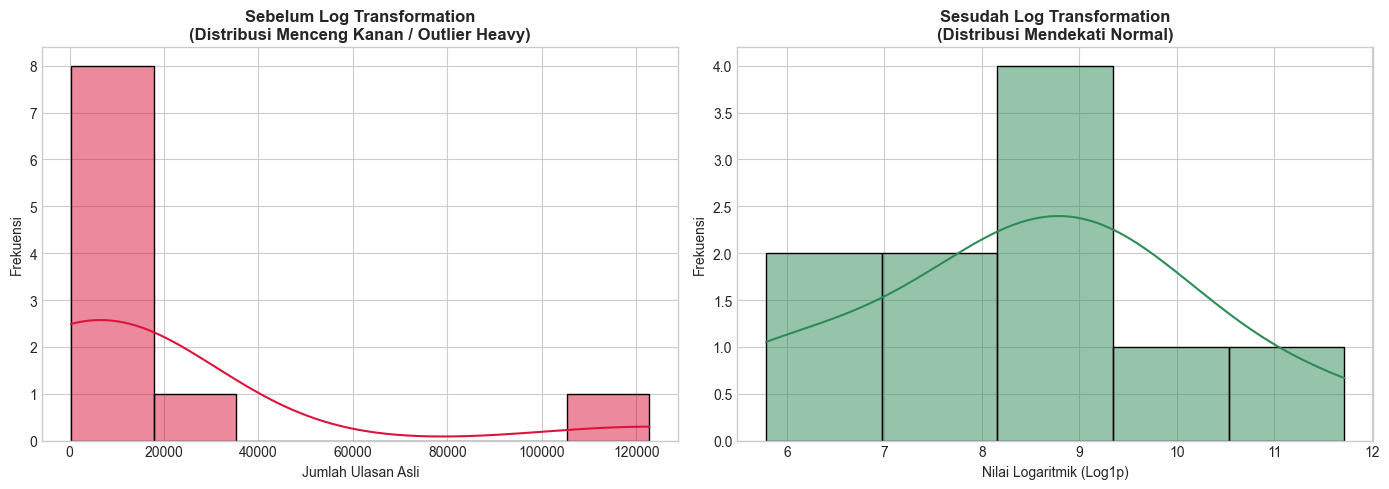

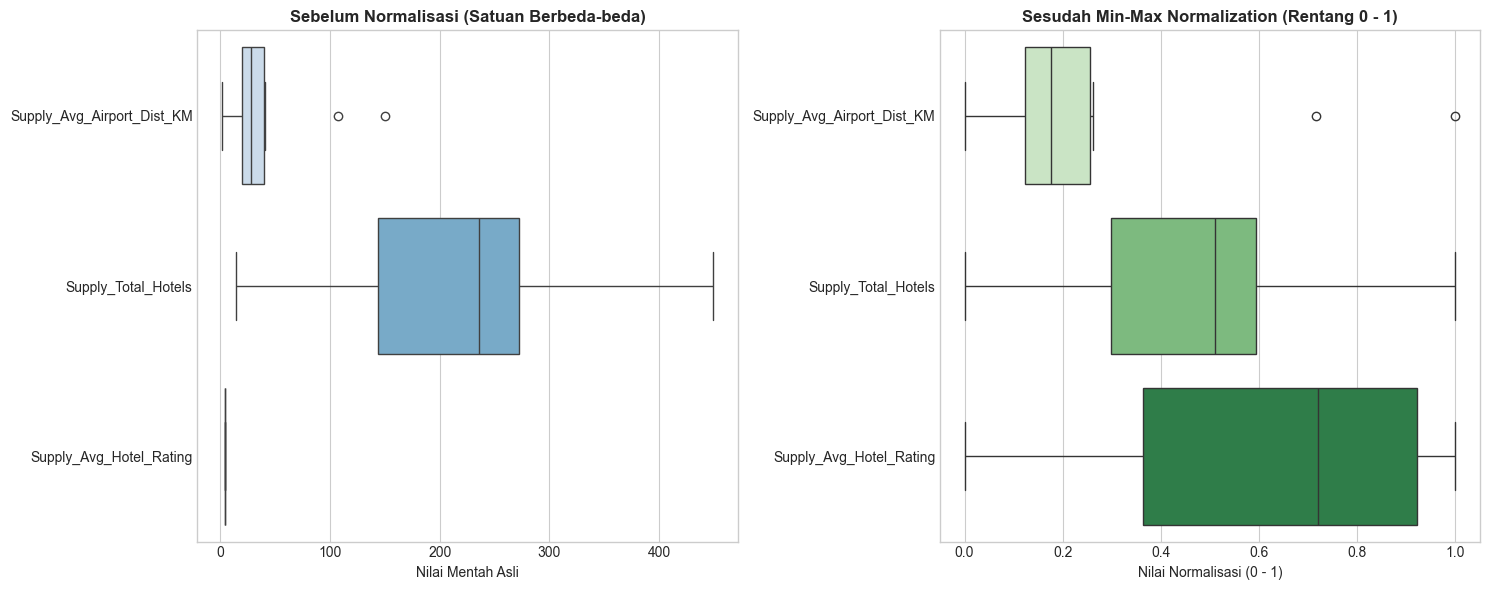

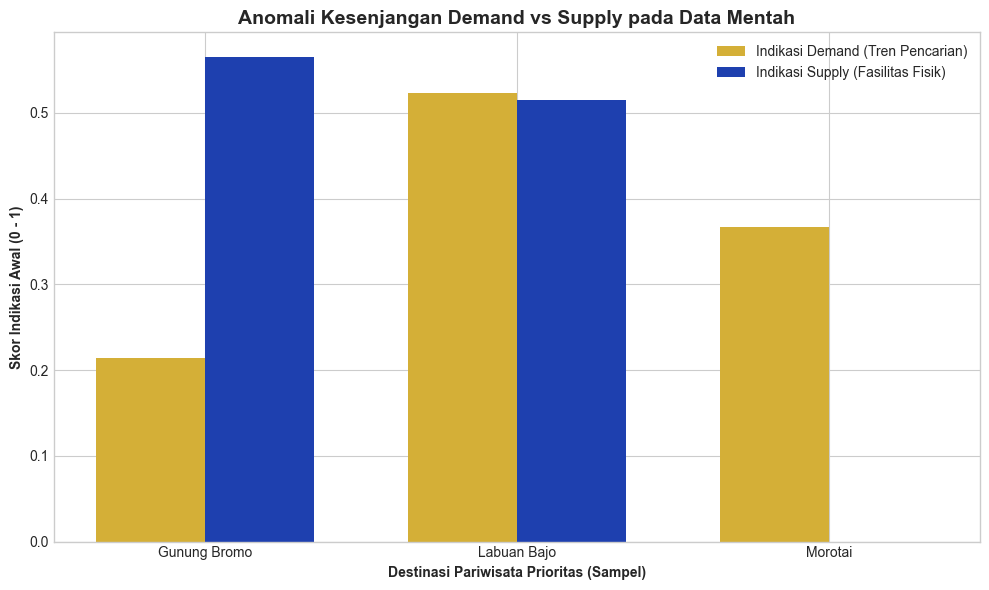

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Pengaturan tema visual agar elegan dan profesional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

# =========================================================
# 1. LOAD DATA MASTER (Simulasi Penggabungan Data)
# =========================================================
try:
    df_demand = pd.read_csv('master_demand_matrix_final.csv')
    df_supply = pd.read_csv('master_supply_matrix_updated_with_revisions.csv')
    df_eda = pd.merge(df_demand, df_supply, on='DPP')
    
    # Menyelaraskan nama DPP sesuai website resmi
    df_eda['DPP'] = df_eda['DPP'].replace({'Tanjung Kelayang': 'Bangka Belitung', 'Bromo': 'Gunung Bromo'})
except FileNotFoundError:
    print("Pastikan file CSV demand dan supply berada di folder yang sama.")

# =========================================================
# PLOT 1: Distribusi Data Demand yang Sangat Menceng (Right-Skewed)
# Menggambarkan poin 1 pada laporan (Efek sebelum & sesudah Log Transformation)
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Memilih satu fitur demand yang paling rentan viral (misal: GoogleMaps_Total_Reviews atau TikTok Views)
# Jika kolom TikTok tidak ada, sesuaikan dengan nama kolom yang tersedia di dataset Anda.
skewed_feature = 'GoogleMaps_Total_Reviews' 

# Histogram Sebelum Log Transformation
sns.histplot(df_eda[skewed_feature], kde=True, ax=axes[0], color='crimson')
axes[0].set_title(f'Sebelum Log Transformation\n(Distribusi Menceng Kanan / Outlier Heavy)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Ulasan Asli')
axes[0].set_ylabel('Frekuensi')

# Histogram Sesudah Log Transformation
log_transformed_data = np.log1p(df_eda[skewed_feature])
sns.histplot(log_transformed_data, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'Sesudah Log Transformation\n(Distribusi Mendekati Normal)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nilai Logaritmik (Log1p)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('EDA_1_Skewed_Demand.png', dpi=300)
plt.show()

# =========================================================
# PLOT 2: Heterogenitas Satuan Data Supply 
# Menggambarkan poin 2 pada laporan (Kenapa butuh Min-Max Scaling)
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Memilih 3 fitur dengan satuan berbeda (Jarak dalam KM, Jumlah dalam Unit, Rating dalam Skala 1-5)
supply_heterogen = ['Supply_Avg_Airport_Dist_KM', 'Supply_Total_Hotels', 'Supply_Avg_Hotel_Rating']

# Boxplot Sebelum Normalisasi (Skala Jauh Berbeda)
sns.boxplot(data=df_eda[supply_heterogen], ax=axes[0], orient='h', palette='Blues')
axes[0].set_title('Sebelum Normalisasi (Satuan Berbeda-beda)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nilai Mentah Asli')

# Boxplot Sesudah Min-Max Normalization (Skala Seragam 0-1)
scaler = MinMaxScaler()
supply_normalized = pd.DataFrame(scaler.fit_transform(df_eda[supply_heterogen]), columns=supply_heterogen)

sns.boxplot(data=supply_normalized, ax=axes[1], orient='h', palette='Greens')
axes[1].set_title('Sesudah Min-Max Normalization (Rentang 0 - 1)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nilai Normalisasi (0 - 1)')

plt.tight_layout()
plt.savefig('EDA_2_Heterogen_Supply.png', dpi=300)
plt.show()

# =========================================================
# PLOT 3 REVISI: Indikasi Awal Ketimpangan (Gap)
# Memastikan konsistensi narasi Bromo sebagai kawasan Over-Demand
# =========================================================
# Kita gunakan Search Volume atau metrik logaritmik sebagai proxy demand agar lebih akurat
df_eda['Proxy_Demand_Raw'] = MinMaxScaler().fit_transform(df_eda[['Search_Volume_Score']]) # atau gunakan metrik yang relevan
df_eda['Proxy_Supply_Raw'] = MinMaxScaler().fit_transform(df_eda[['Supply_Total_Hotels']])

# Mengambil contoh 3 destinasi ekstrem
sample_dpp = df_eda[df_eda['DPP'].isin(['Gunung Bromo', 'Labuan Bajo', 'Morotai'])]

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(sample_dpp))

# Bromo sekarang akan menunjukkan Demand kuning yang tinggi
bar1 = ax.bar(index, sample_dpp['Proxy_Demand_Raw'], bar_width, label='Indikasi Demand (Tren Pencarian)', color='#D4AF37')
bar2 = ax.bar(index + bar_width, sample_dpp['Proxy_Supply_Raw'], bar_width, label='Indikasi Supply (Fasilitas Fisik)', color='#1E40AF')

ax.set_xlabel('Destinasi Pariwisata Prioritas (Sampel)', fontweight='bold')
ax.set_ylabel('Skor Indikasi Awal (0 - 1)', fontweight='bold')
ax.set_title('Anomali Kesenjangan Demand vs Supply pada Data Mentah', fontsize=14, fontweight='bold')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(sample_dpp['DPP'])
ax.legend()

plt.tight_layout()
plt.savefig('EDA_3_Indikasi_Gap_Revisi.png', dpi=300)
plt.show()

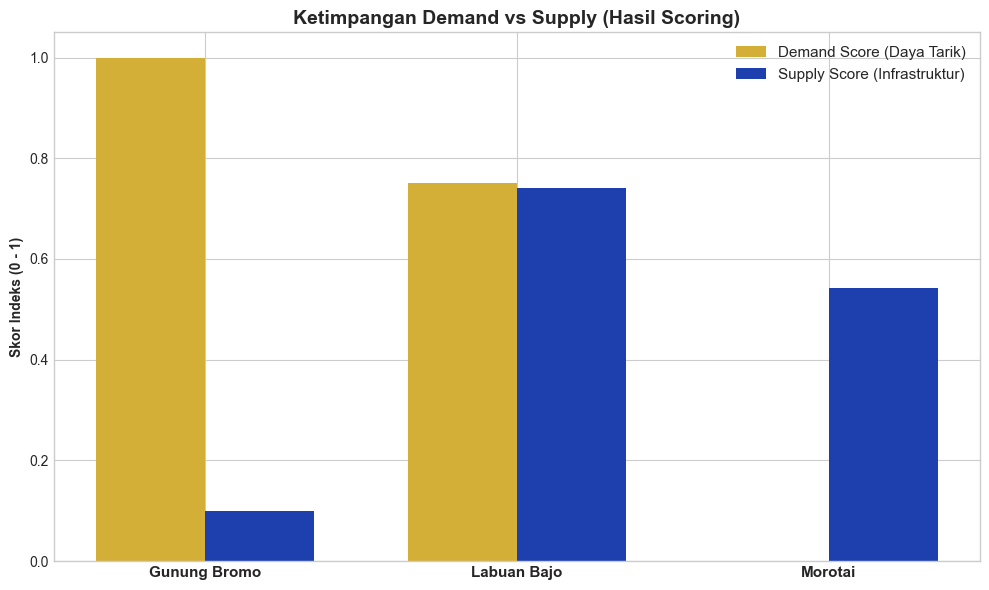

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Pengaturan tema visual
plt.style.use('seaborn-v0_8-whitegrid')

# Data aktual berdasarkan hasil final scoring di PPT/Dashboard Anda
destinations = ['Gunung Bromo', 'Labuan Bajo', 'Morotai']
demand_scores = [1.000, 0.750, 0.000] # Bromo over-demand, Morotai krisis
supply_scores = [0.099, 0.740, 0.542] # Bromo krisis supply, Labuan Bajo seimbang

x = np.arange(len(destinations))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Membuat Bar Chart
rects1 = ax.bar(x - width/2, demand_scores, width, label='Demand Score (Daya Tarik)', color='#D4AF37')
rects2 = ax.bar(x + width/2, supply_scores, width, label='Supply Score (Infrastruktur)', color='#1E40AF')

# Kustomisasi teks dan label
ax.set_ylabel('Skor Indeks (0 - 1)', fontweight='bold')
ax.set_title('Ketimpangan Demand vs Supply (Hasil Scoring)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(destinations, fontweight='bold', fontsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('EDA_3_Indikasi_Gap_Final.png', dpi=300)
plt.show()

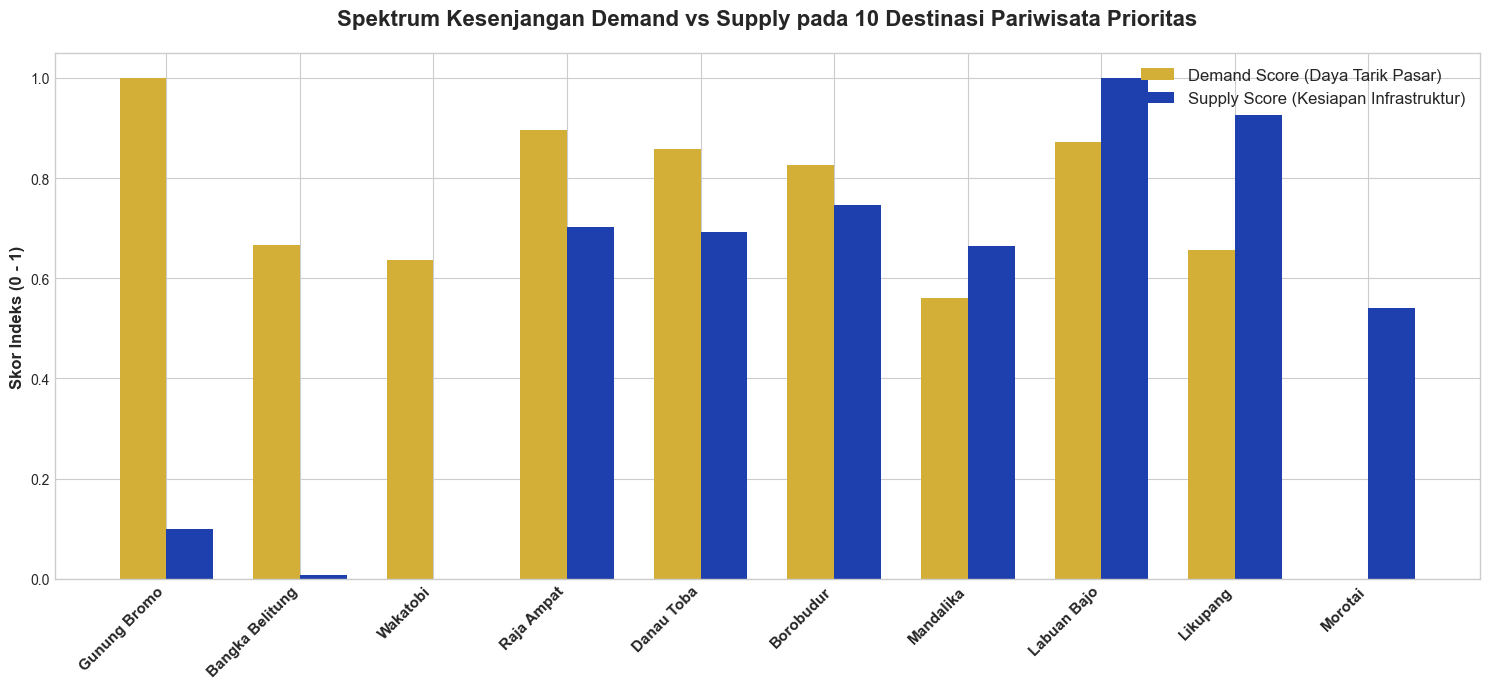

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pengaturan tema visual
plt.style.use('seaborn-v0_8-whitegrid')

try:
    # 1. Load data final hasil scoring (pastikan nama file sesuai)
    df_final = pd.read_csv('final_dashboard_dataset_K3.csv')
    
    # 2. Sesuaikan penamaan agar konsisten dengan laporan
    df_final['DPP'] = df_final['DPP'].replace({
        'Tanjung Kelayang': 'Bangka Belitung', 
        'Bromo': 'Gunung Bromo'
    })
    
    # 3. Urutkan berdasarkan Gap (Demand - Supply) dari yang paling positif ke negatif
    df_final['Gap_Analysis'] = df_final['Demand_Score'] - df_final['Supply_Score']
    df_final = df_final.sort_values('Gap_Analysis', ascending=False).reset_index(drop=True)

    # 4. Persiapan Plot
    x = np.arange(len(df_final))
    width = 0.35

    fig, ax = plt.subplots(figsize=(15, 7))

    # Membuat Bar Chart berdampingan
    rects1 = ax.bar(x - width/2, df_final['Demand_Score'], width, label='Demand Score (Daya Tarik Pasar)', color='#D4AF37')
    rects2 = ax.bar(x + width/2, df_final['Supply_Score'], width, label='Supply Score (Kesiapan Infrastruktur)', color='#1E40AF')

    # Kustomisasi teks dan label
    ax.set_ylabel('Skor Indeks (0 - 1)', fontweight='bold', fontsize=12)
    ax.set_title('Spektrum Kesenjangan Demand vs Supply pada 10 Destinasi Pariwisata Prioritas', fontsize=16, fontweight='bold', pad=20)
    
    # Menambahkan nama destinasi di sumbu X dengan kemiringan 45 derajat agar rapi
    ax.set_xticks(x)
    ax.set_xticklabels(df_final['DPP'], rotation=45, ha='right', fontweight='bold', fontsize=11)
    
    ax.legend(fontsize=12, loc='upper right')

    plt.tight_layout()
    plt.savefig('EDA_3_Indikasi_Gap_All_10.png', dpi=300)
    plt.show()

except FileNotFoundError:
    print("File 'final_dashboard_dataset_K3.csv' tidak ditemukan. Pastikan file tersebut berada di folder yang sama dengan script ini.")